
<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2e75b6 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
<h1 style="font-size: 2.5em; margin-bottom: 10px;">🧹 Olist E-Commerce</h1>
<h2 style="font-weight: 300; font-size: 1.5em; margin-bottom: 20px;">Data Cleaning Notebook</h2>
<p style="font-size: 1.1em; opacity: 0.85;" >Step 2 of 6 · integration → <b>EDA</b> → Cleaning → Feature Engineering → Preprocessing → Modeling</p>
</div>

---

## What This Notebook Does

| Step | Action | Reason |
|---|---|---|
| **1** | Imports & load data | Start fresh from merged CSV |
| **2** | Snapshot before cleaning | Know what we started with |
| **3** | Filter to delivered orders | Non-delivered have no review/delivery date |
| **4** | Drop high-missing columns | 58–88% missing, not usable |
| **5** | Drop missing delivery dates | True data quality errors post-filter |
| **6** | Drop missing review scores | Can't model without the target |
| **7** | Impute product dimensions | Category-level median — smarter than global |
| **8** | Fill missing categories | Replace with 'unknown' |
| **9** | Drop remaining null rows | Payment, seller, price — very few |
| **10** | Cap price/freight outliers | Prevent extreme values from distorting models |
| **11** | Validate & save | Final check + export clean CSV |



---
# 📦 Chapter 1 — Setting the Scene

> Before any analysis, we need to understand what we're working with. How big is this dataset? Is it clean? What time period does it cover?

We start by loading the merged Olist dataset and taking a first look at its structure.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

In [23]:
df = pd.read_csv('olist_merged.csv')
print(df.shape)
df.head()

(119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto


In [24]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
order_item_id                           float64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           float64
payment_sequential                      float64
payment_type                             object
payment_installments                    


### 🔍 First Look — Shape & Types

The dataset has **119,143 rows and 40 columns**, combining orders, customers, products, sellers, payments, and reviews into a single flat table.


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [26]:
print("Data shape is:", df.shape)
print("=============================================================")
print("Duplicates:",df.duplicated().sum())
print("=============================================================")
print(df.dtypes.value_counts())
print("=============================================================")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(df.describe().T)

Data shape is: (119143, 40)
Duplicates: 0
object            17
float64           15
datetime64[ns]     7
int64              1
Name: count, dtype: int64
review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_category_name_english      2567
product_name_lenght                2542
product_description_lenght         2542
product_category_name              2542
product_photos_qty                 2542
order_delivered_carrier_date       2086
review_id                           997
review_answer_timestamp             997
review_score                        997
review_creation_date                997
product_height_cm                   853
product_length_cm                   853
dtype: int64
                                  count                           mean  \
order_purchase_timestamp         119143  2017-12-29 18:36:13.115760128   
order_approved_at                118966  2017-12-30 04:49:18.425726976   
order_deliver


### 🧩 Missing Values — Where are the gaps?

Not all columns are complete. Understanding *why* values are missing is just as important as knowing *how many* are missing.


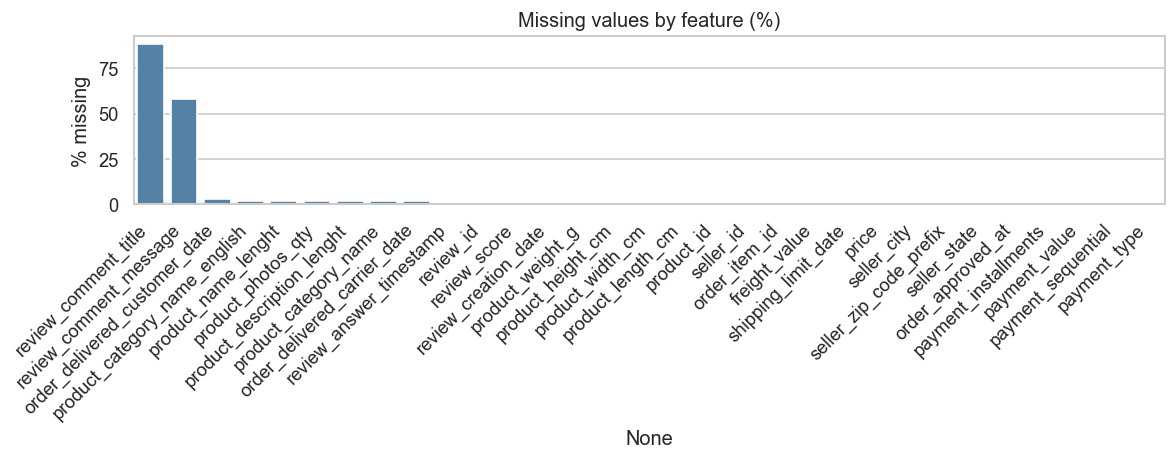

In [27]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'count': nulls, 'percentage': null_pct})
null_df = null_df[null_df['count'] > 0].sort_values('percentage', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=null_df.index, y='percentage', data=null_df, color='steelblue')
plt.title('Missing values by feature (%)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('% missing')
plt.tight_layout()
plt.show()



**Key observations:**
- `review_comment_title` (88% missing) and `review_comment_message` (58% missing) are **optional fields** — customers aren't required to write anything
- `order_delivered_customer_date` nulls (~3,400) are **structurally expected** — cancelled or in-transit orders have no delivery date
- Product dimension nulls (~850 rows) are **data quality gaps** — imputable with category medians
- **No duplicate rows** — the merge was clean

> ✅ **Decision:** Drop comment columns for ML. Filter to `delivered` orders for delivery/review modeling. Impute product dimension nulls with category medians.


In [28]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,119143,2017-12-29 18:36:13.115760128,2016-09-04 21:15:19,2017-09-10 20:15:46,2018-01-17 11:59:12,2018-05-03 13:18:30,2018-10-17 17:30:18,NaN
order_approved_at,118966,2017-12-30 04:49:18.425726976,2016-09-15 12:16:38,2017-09-11 15:50:48.500000,2018-01-17 16:49:49,2018-05-03 16:56:53,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,117057,2018-01-03 08:24:34.395524864,2016-10-08 10:34:01,2017-09-14 19:52:12,2018-01-23 17:03:08,2018-05-07 14:57:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,115722,2018-01-12 20:55:38.199616,2016-10-11 13:46:32,2017-09-22 21:54:31.249999872,2018-02-01 03:17:55,2018-05-15 00:08:31.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,119143,2018-01-22 15:21:10.241642240,2016-09-30 00:00:00,2017-10-02 00:00:00,2018-02-14 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
customer_zip_code_prefix,119143.0,35033.451298,1003.0,11250.0,24240.0,58475.0,99990.0,29823.198969
order_item_id,118310.0,1.196543,1.0,1.0,1.0,1.0,21.0,0.699489
price,118310.0,120.646603,0.85,39.9,74.9,134.9,6735.0,184.109691
freight_value,118310.0,20.032387,0.0,13.08,16.28,21.18,409.68,15.83685
payment_sequential,119140.0,1.094737,1.0,1.0,1.0,1.0,29.0,0.730141


In [29]:
df.describe(include='object').T

,count,unique,top,freq
order_id,119143,99441,895ab968e7bb0d5659d16cd74cd1650c,63
customer_id,119143,99441,270c23a11d024a44c896d1894b261a83,63
order_status,119143,8,delivered,115723
customer_unique_id,119143,96096,9a736b248f67d166d2fbb006bcb877c3,75
customer_city,119143,4119,sao paulo,18875
customer_state,119143,27,SP,50265
product_id,118310,32951,aca2eb7d00ea1a7b8ebd4e68314663af,536
seller_id,118310,3095,4a3ca9315b744ce9f8e9374361493884,2155
shipping_limit_date,118310,93318,2017-08-14 20:43:31,63
payment_type,119140,5,credit_card,87776



---
# 🌱 Chapter 2 — The Marketplace

> Olist launched in 2015 as a marketplace connecting small Brazilian retailers to major e-commerce platforms. By 2016, it was growing fast. How fast? And where?

## 2.1 — Order Status: What happens to orders?


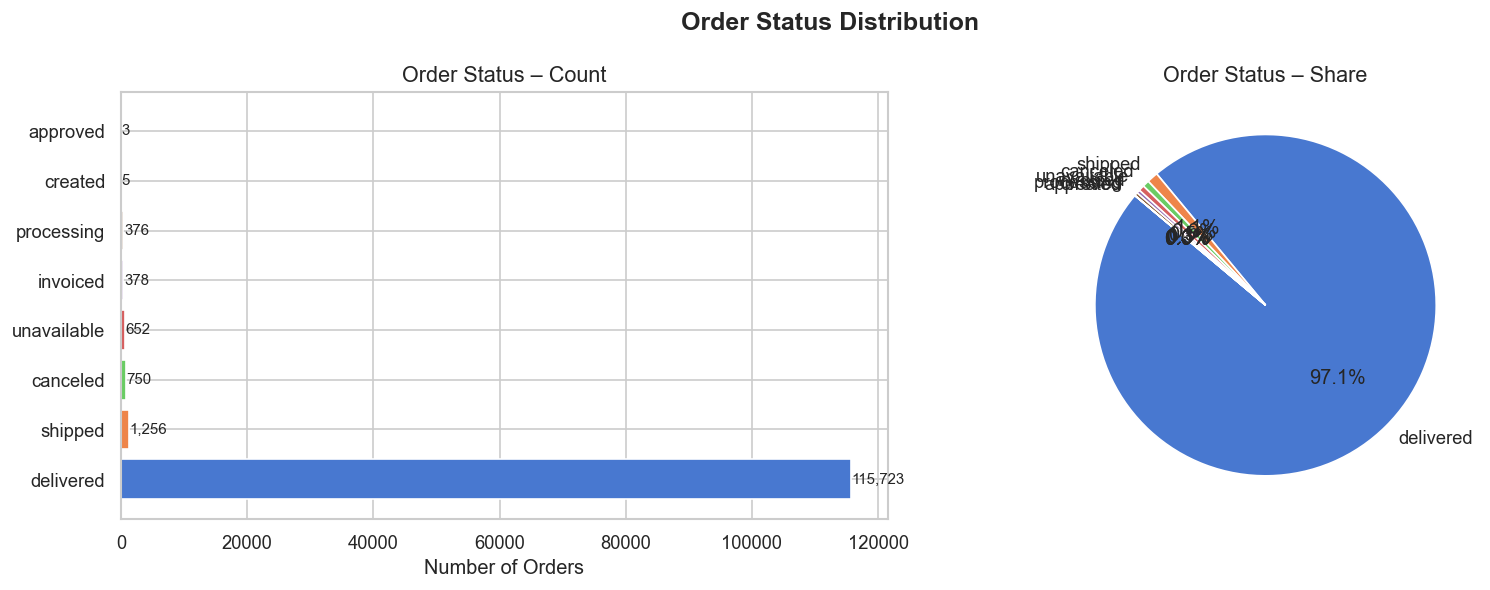

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3


In [30]:

status_counts = df['order_status'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(status_counts.index, status_counts.values, color=sns.color_palette('muted', len(status_counts)))
axes[0].set_title('Order Status – Count', fontsize=13)
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(status_counts.values):
    axes[0].text(v + 100, i, f"{v:,}", va='center', fontsize=9)

axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(status_counts)), startangle=140)
axes[1].set_title('Order Status – Share', fontsize=13)

plt.suptitle('Order Status Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(status_counts.to_string())



**97.1% of orders are successfully delivered** — a remarkably strong fulfilment rate. Cancellations (0.6%) are rare, which means the platform runs smoothly but also means cancellation prediction will face severe class imbalance in ML.

---

## 2.2 — Growth Over Time: The rocket ship


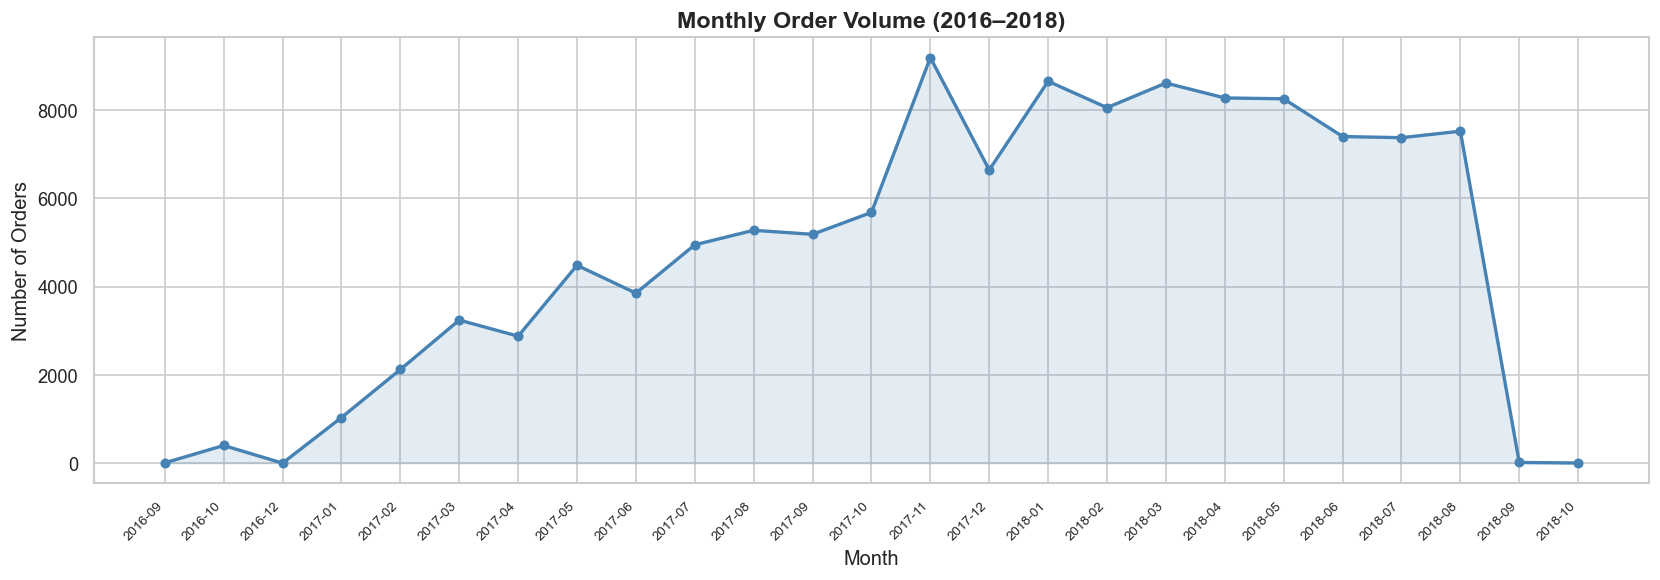

In [31]:

df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('year_month').size().reset_index(name='order_count')
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_orders['year_month_str'], monthly_orders['order_count'],
        marker='o', linewidth=2, color='steelblue', markersize=5)
ax.fill_between(monthly_orders['year_month_str'], monthly_orders['order_count'],
                alpha=0.15, color='steelblue')
ax.set_title('Monthly Order Volume (2016–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()



The growth curve tells a clear story:
- **2016:** Early days, low volume — the platform finding its feet
- **2017:** Exponential growth kicks in
- **Nov 2017:** A sharp spike — **Black Friday**, Brazil's biggest shopping event
- **2018:** Steady high volume through mid-year, then a drop-off as data collection ended

> 📌 **Feature idea:** `is_black_friday`, `purchase_month`, `purchase_quarter` — time-based features will carry strong signal.

---

## 2.3 — When Do People Shop?


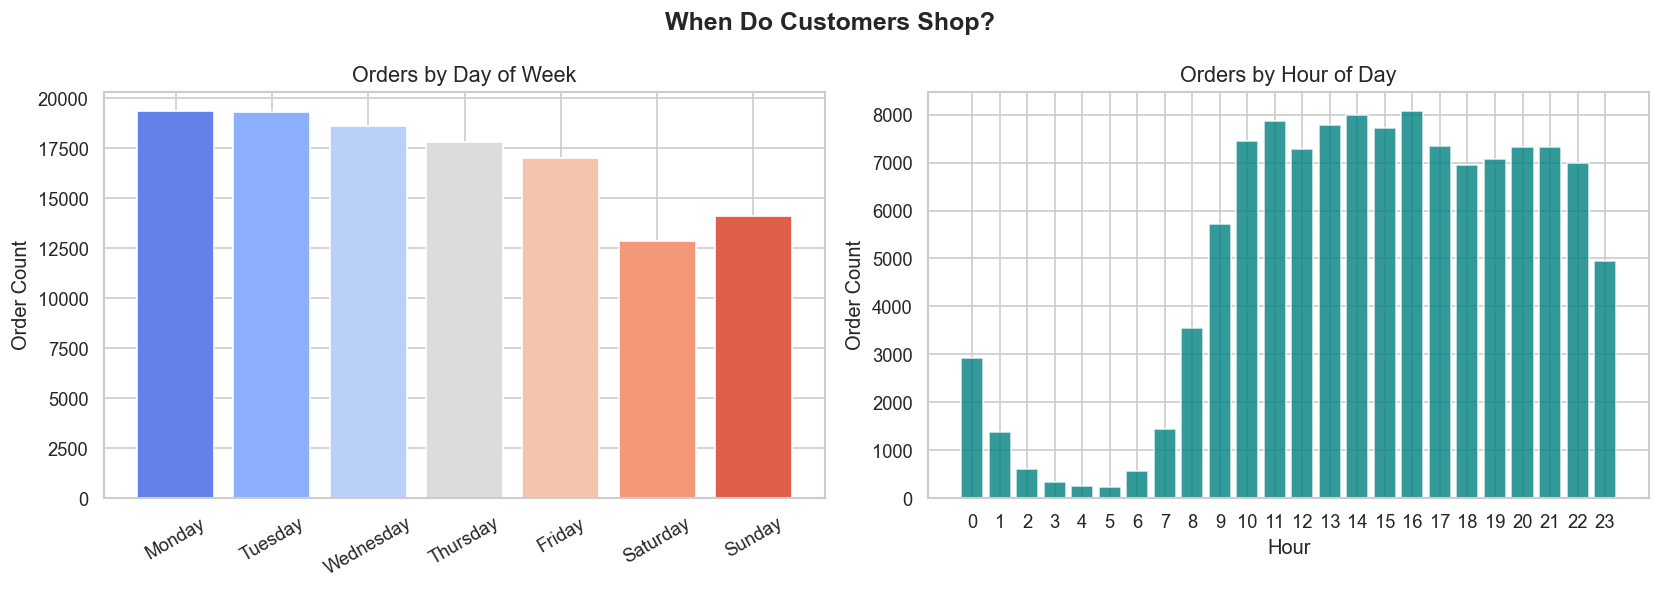

In [32]:

df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['hour'] = df['order_purchase_timestamp'].dt.hour

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(day_counts.index, day_counts.values, color=sns.color_palette('coolwarm', 7))
axes[0].set_title('Orders by Day of Week', fontsize=13)
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=30)

hour_counts = df['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='teal', alpha=0.8)
axes[1].set_title('Orders by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Order Count')
axes[1].set_xticks(range(0, 24))

plt.suptitle('When Do Customers Shop?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



Brazilians shop like most people — **during business hours on weekdays**:
- Peak activity runs **10:00 to 20:00**
- Monday and Tuesday see the highest volume (weekend browsing → weekday purchasing)
- Late night (22:00+) drops sharply

> 📌 **Feature idea:** `purchase_hour`, `is_weekend` — useful for fraud detection and urgency modeling.

---

## 2.4 — Geography: A São Paulo story


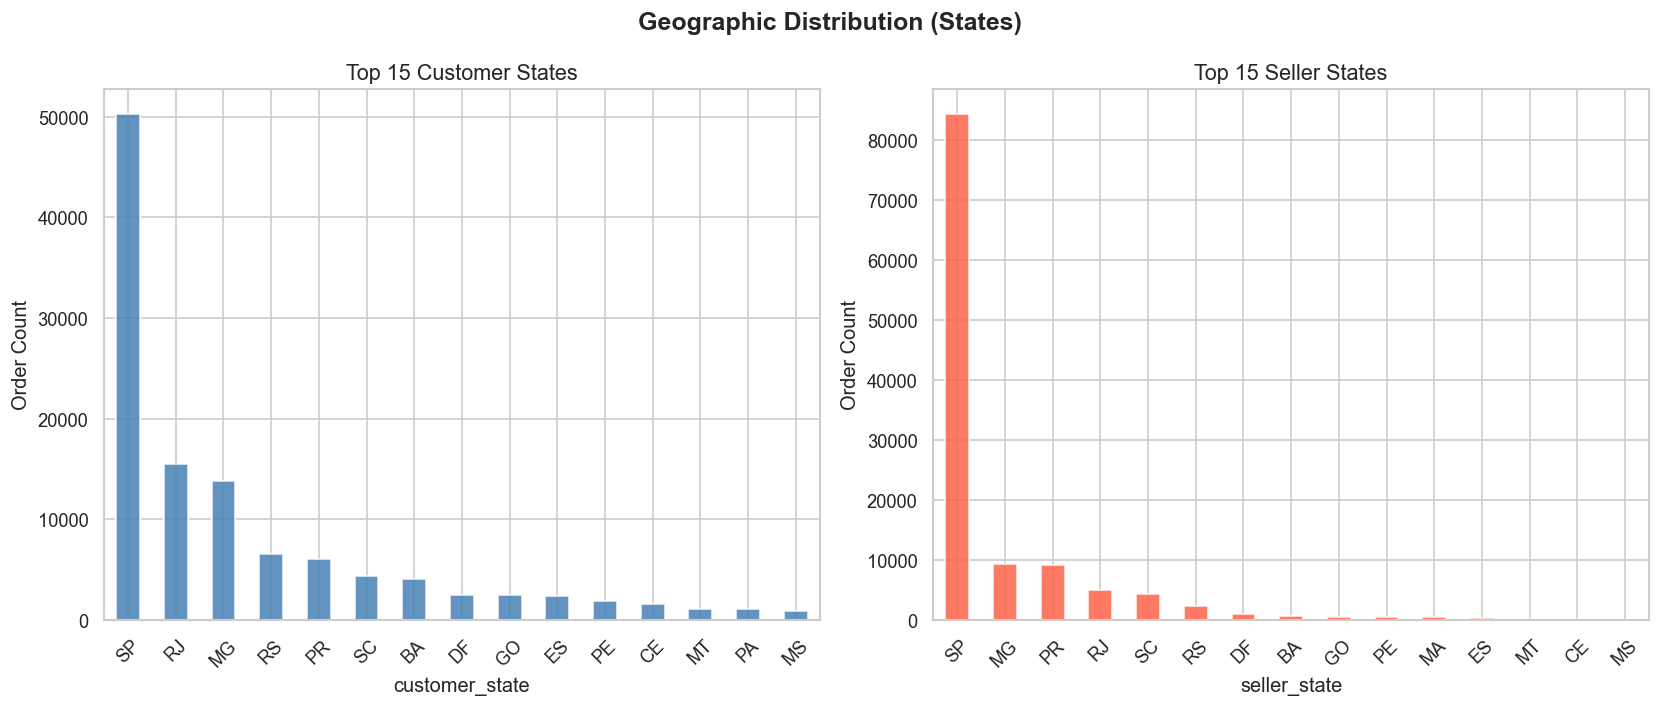

In [33]:

top_n = 15
cust_state = df['customer_state'].value_counts().head(top_n)
sell_state = df['seller_state'].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cust_state.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title(f'Top {top_n} Customer States', fontsize=13)
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=45)

sell_state.plot(kind='bar', ax=axes[1], color='tomato', alpha=0.85)
axes[1].set_title(f'Top {top_n} Seller States', fontsize=13)
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Geographic Distribution (States)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



The geographic concentration is striking:
- **São Paulo (SP)** accounts for ~42% of customers and ~71% of sellers
- The seller-customer geographic mismatch is significant: customers in the North and Northeast are buying from sellers concentrated in the South and Southeast
- This gap directly drives up freight costs and delivery times for remote states

> 📌 **Feature idea:** `same_state` flag (customer vs seller), or a state-pair distance proxy — one of the strongest drivers of freight cost and delivery time.



---
# 🛍️ Chapter 3 — The Products

> Brazil's middle class loves home goods, beauty products, and consumer electronics. The category mix tells us what Olist's customers actually need — and what earns the most money.

## 3.1 — What Sells Most?


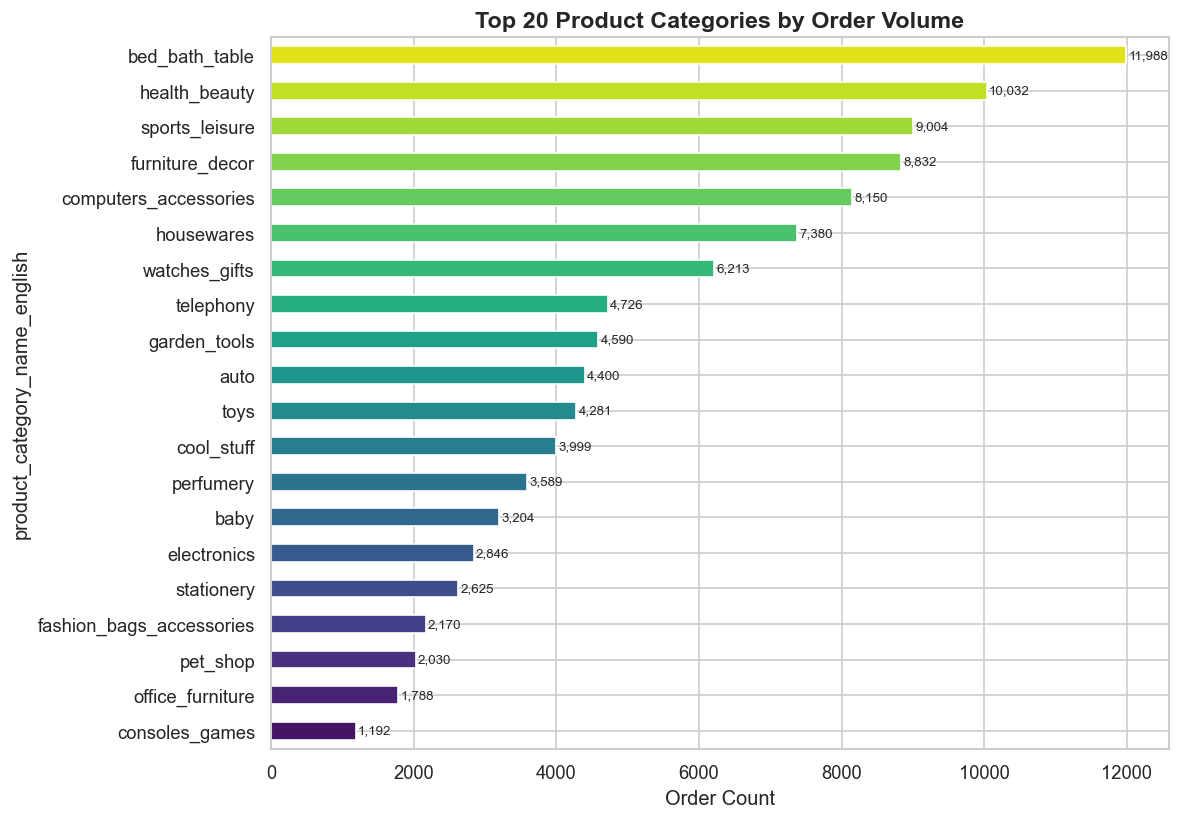

In [34]:

top_cats = df['product_category_name_english'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_cats[::-1].plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 20))
ax.set_title('Top 20 Product Categories by Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Count')
for i, v in enumerate(top_cats.values[::-1]):
    ax.text(v + 30, i, f"{v:,}", va='center', fontsize=8)
plt.tight_layout()
plt.show()



**Bed, bath & table** leads by a wide margin — home goods are the platform's heartbeat. Health & beauty, sports, furniture, and electronics round out the top 5. With 73 categories total, there's long-tail variety, but the top 10 categories drive the majority of volume.

---

## 3.2 — What Earns Most?


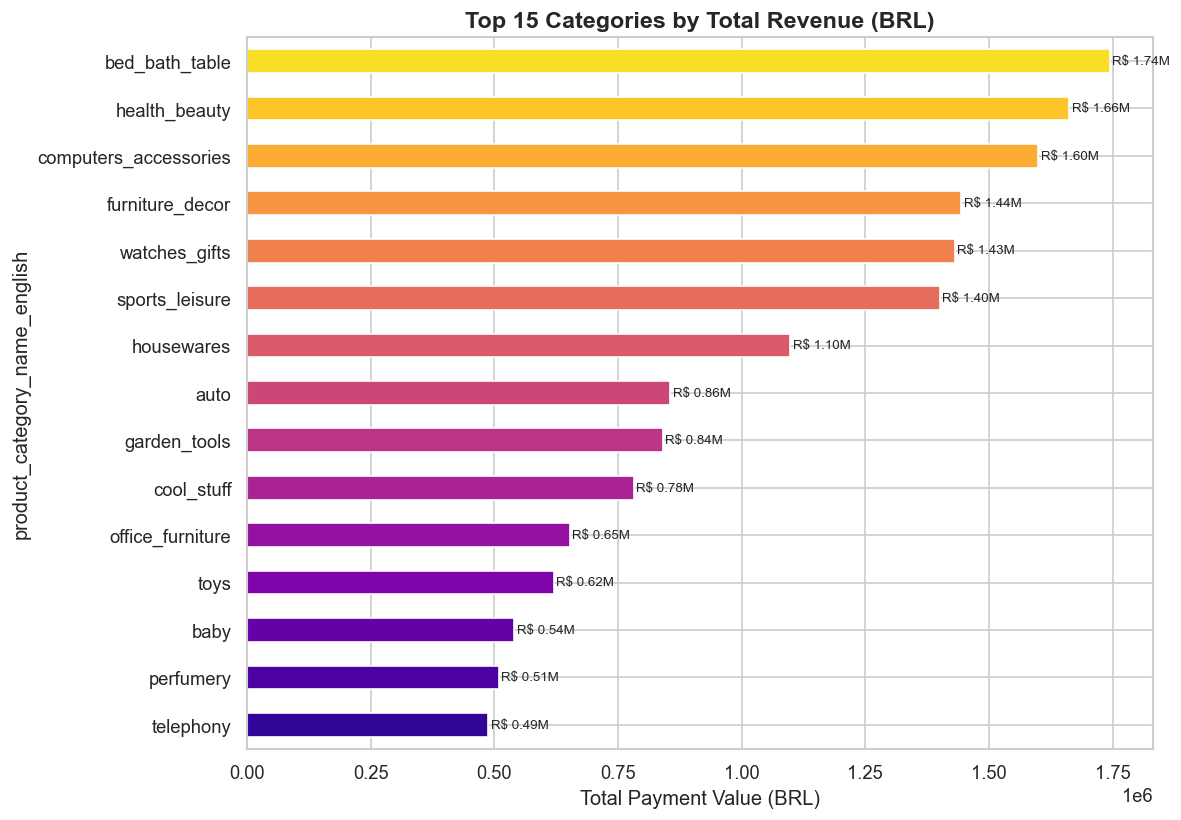

In [35]:

cat_revenue = df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
cat_revenue[::-1].plot(kind='barh', ax=ax, color=sns.color_palette('plasma', 15))
ax.set_title('Top 15 Categories by Total Revenue (BRL)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Payment Value (BRL)')
for i, v in enumerate(cat_revenue.values[::-1]):
    ax.text(v + 5000, i, f"R$ {v/1e6:.2f}M", va='center', fontsize=8)
plt.tight_layout()
plt.show()



Here's where it gets interesting — **volume ≠ revenue**:
- `health_beauty` tops revenue despite not being #1 in volume → higher price per order
- `watches_gifts` and `computers` punch above their weight → expensive items
- `bed_bath_table` is the consistent performer across both volume and revenue

---

## 3.3 — What's Actually Profitable?

After accounting for freight costs, some categories have surprisingly thin margins.


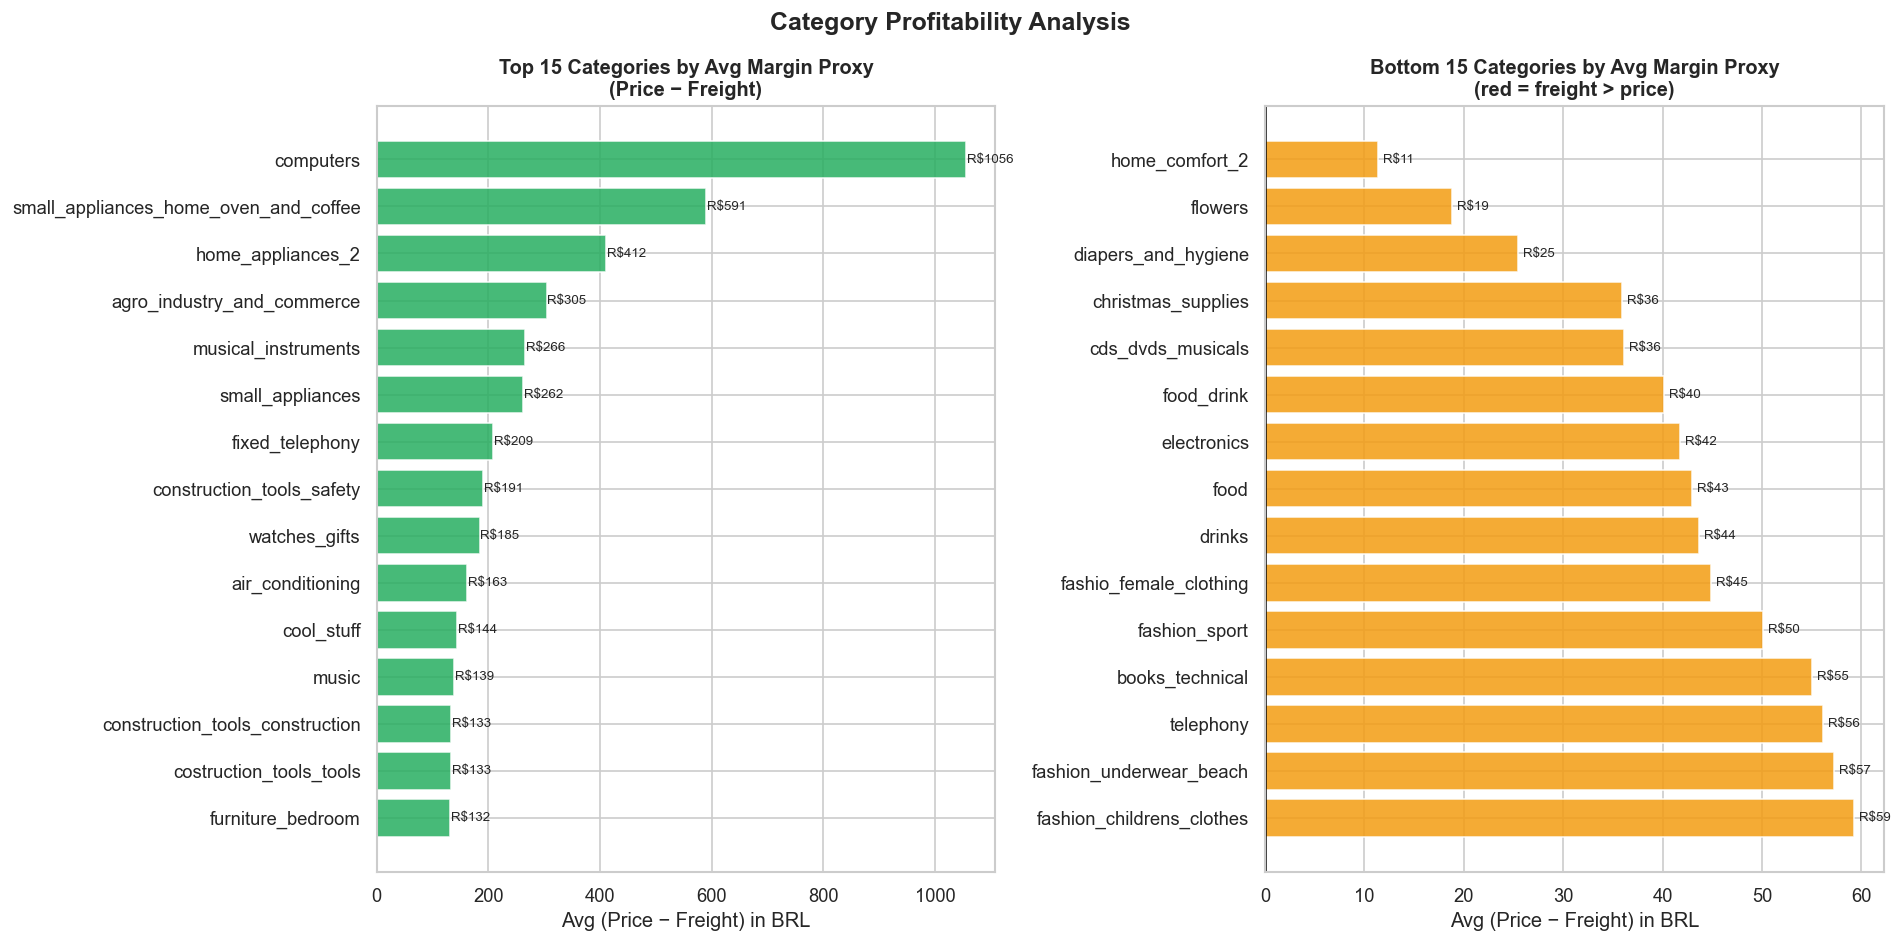

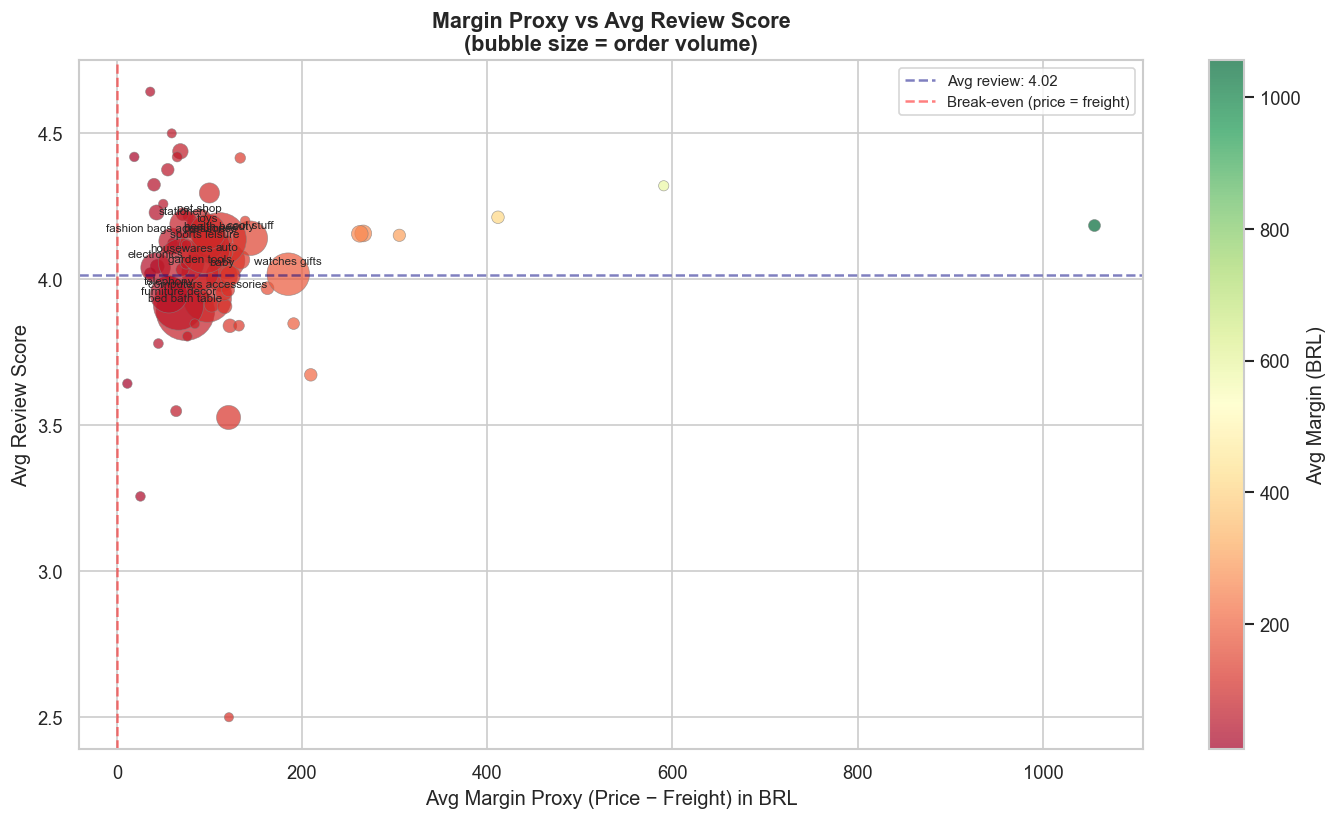


Categories where freight exceeds price (negative margin):
Empty DataFrame
Columns: [product_category_name_english, avg_price, avg_freight, avg_margin, order_count]
Index: []


In [36]:

df['margin_proxy'] = df['price'] - df['freight_value']

cat_profit = df.groupby('product_category_name_english').agg(
    avg_margin=('margin_proxy', 'mean'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    order_count=('order_id', 'count'),
    avg_review=('review_score', 'mean')
).reset_index().dropna()

# Top and bottom 15 by margin
top15 = cat_profit.nlargest(15, 'avg_margin')
bot15 = cat_profit.nsmallest(15, 'avg_margin')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15
top15_sorted = top15.sort_values('avg_margin')
axes[0].barh(top15_sorted['product_category_name_english'],
             top15_sorted['avg_margin'],
             color='#27AE60', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 15 Categories by Avg Margin Proxy\n(Price − Freight)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg (Price − Freight) in BRL')
for i, v in enumerate(top15_sorted['avg_margin']):
    axes[0].text(v + 1, i, f'R${v:.0f}', va='center', fontsize=8)

# Bottom 15
bot15_sorted = bot15.sort_values('avg_margin', ascending=False)
colors_bot = ['#E74C3C' if v < 0 else '#F39C12' for v in bot15_sorted['avg_margin']]
axes[1].barh(bot15_sorted['product_category_name_english'],
             bot15_sorted['avg_margin'],
             color=colors_bot, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='-')
axes[1].set_title('Bottom 15 Categories by Avg Margin Proxy\n(red = freight > price)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg (Price − Freight) in BRL')
for i, v in enumerate(bot15_sorted['avg_margin']):
    axes[1].text(v + 0.5, i, f'R${v:.0f}', va='center', fontsize=8)

plt.suptitle('Category Profitability Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Margin vs review score scatter
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(cat_profit['avg_margin'], cat_profit['avg_review'],
                s=cat_profit['order_count']/10 + 30,
                c=cat_profit['avg_margin'], cmap='RdYlGn',
                alpha=0.7, edgecolors='gray', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='Avg Margin (BRL)')

for _, row in cat_profit[cat_profit['order_count'] > 2000].iterrows():
    ax.annotate(row['product_category_name_english'].replace('_',' '),
                (row['avg_margin'], row['avg_review']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('Margin Proxy vs Avg Review Score\n(bubble size = order volume)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Margin Proxy (Price − Freight) in BRL')
ax.set_ylabel('Avg Review Score')
ax.axhline(df['review_score'].mean(), color='navy', linestyle='--', alpha=0.5,
           label=f'Avg review: {df["review_score"].mean():.2f}')
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Break-even (price = freight)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nCategories where freight exceeds price (negative margin):")
neg = cat_profit[cat_profit['avg_margin'] < 0][['product_category_name_english','avg_price','avg_freight','avg_margin','order_count']]
print(neg.sort_values('avg_margin').to_string(index=False))



> 💡 **Insight:** Some categories show a negative margin proxy — freight costs exceed the product price. These are typically heavy, low-value items shipping long distances. For a marketplace, this signals potential pricing strategy issues worth flagging.

> 📌 **Feature idea:** `margin_proxy = price - freight_value`, `freight_ratio` — useful for price and satisfaction modeling.

---

## 3.4 — Outliers: The extremes that skew everything


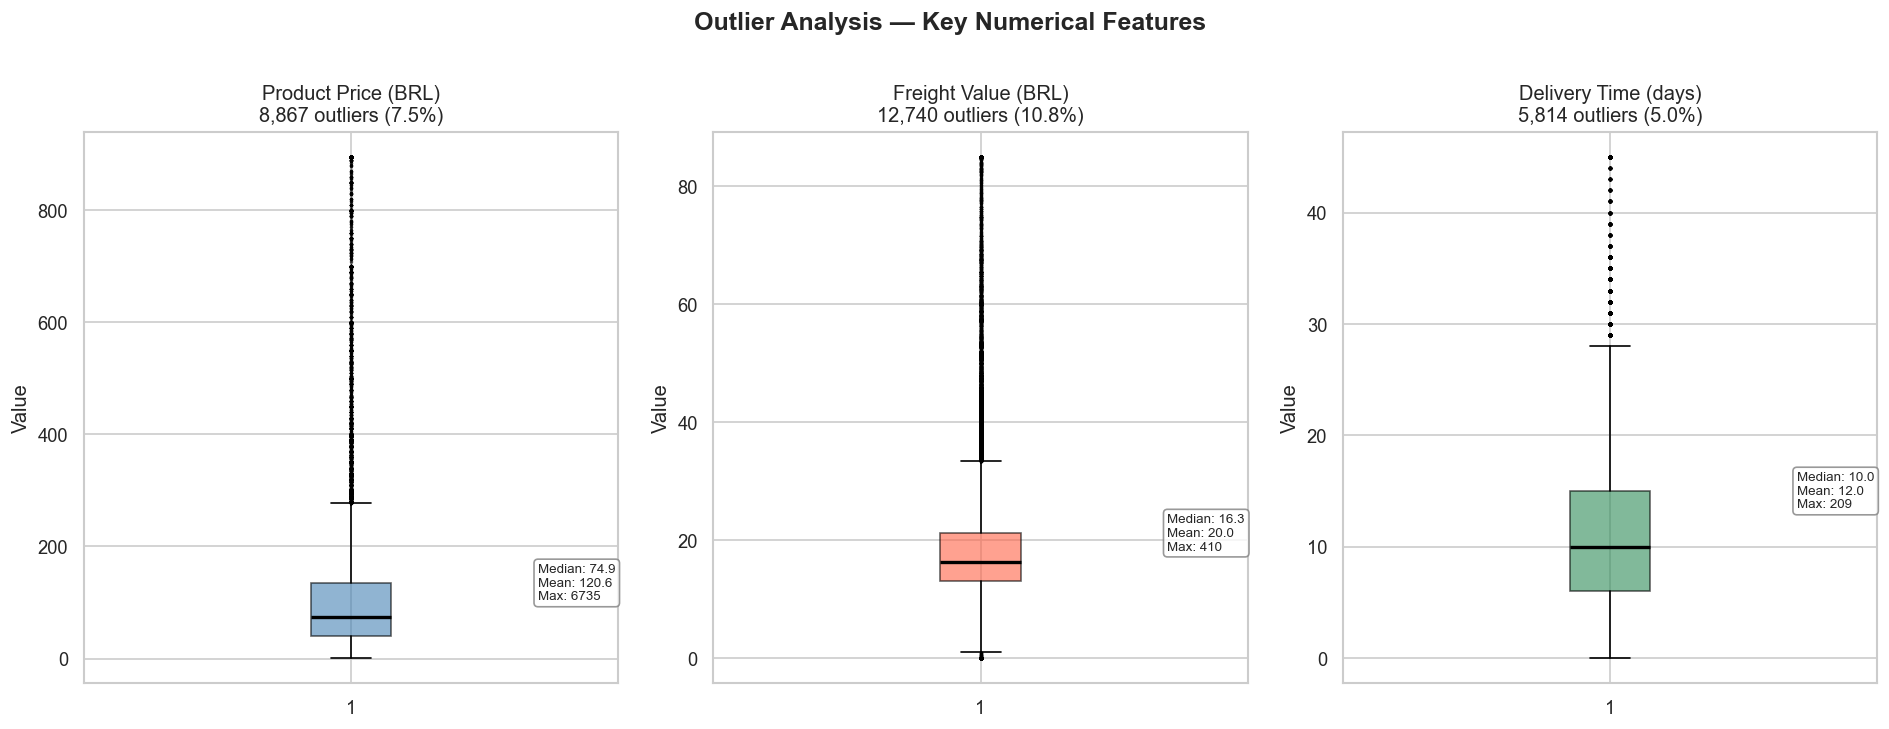

price: IQR=[39.9, 134.9], fence=[0.0, 277.4], outliers=8,867 (7.5%)
freight_value: IQR=[13.1, 21.2], fence=[0.9, 33.3], outliers=12,740 (10.8%)
delivery_days: IQR=[6.0, 15.0], fence=[0.0, 28.5], outliers=5,814 (5.0%)


In [37]:

# Prepare delivery_days if not already done
if 'delivery_days' not in df.columns:
    delivered_mask = df['order_status'] == 'delivered'
    df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

cols = ['price', 'freight_value', 'delivery_days']
titles = ['Product Price (BRL)', 'Freight Value (BRL)', 'Delivery Time (days)']
colors = ['steelblue', 'tomato', 'seagreen']

for ax, col, title, color in zip(axes, cols, titles, colors):
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct_outliers = n_outliers / len(data) * 100

    bp = ax.boxplot(data.clip(upper=data.quantile(0.99)), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3, color=color))
    ax.set_title(f'{title}\n{n_outliers:,} outliers ({pct_outliers:.1f}%)', fontsize=12)
    ax.set_ylabel('Value')

    # Annotate key stats
    stats_text = f'Median: {data.median():.1f}\nMean: {data.mean():.1f}\nMax: {data.max():.0f}'
    ax.text(1.35, data.quantile(0.75), stats_text, fontsize=8, va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.suptitle('Outlier Analysis — Key Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

for col in cols:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((data < lower) | (data > upper)).sum()
    print(f"{col}: IQR=[{q1:.1f}, {q3:.1f}], fence=[{max(0,lower):.1f}, {upper:.1f}], outliers={n:,} ({n/len(data)*100:.1f}%)")



All three key numerical features are **right-skewed with significant outliers**:
- **Price:** A product costing R$6,735 sits in a dataset where the median is R$74.90
- **Freight:** R$409 maximum vs R$16.28 median — remote deliveries are brutal
- **Delivery days:** Some orders took 30+ days while most arrive in under 2 weeks

> ✅ **Preprocessing decision:** Apply `log1p()` transformation to price, freight, and payment value before any ML modeling.



---
# 💳 Chapter 4 — The Money

> How do Brazilians pay? The answer reveals a lot about consumer behaviour and financial culture in Brazil.


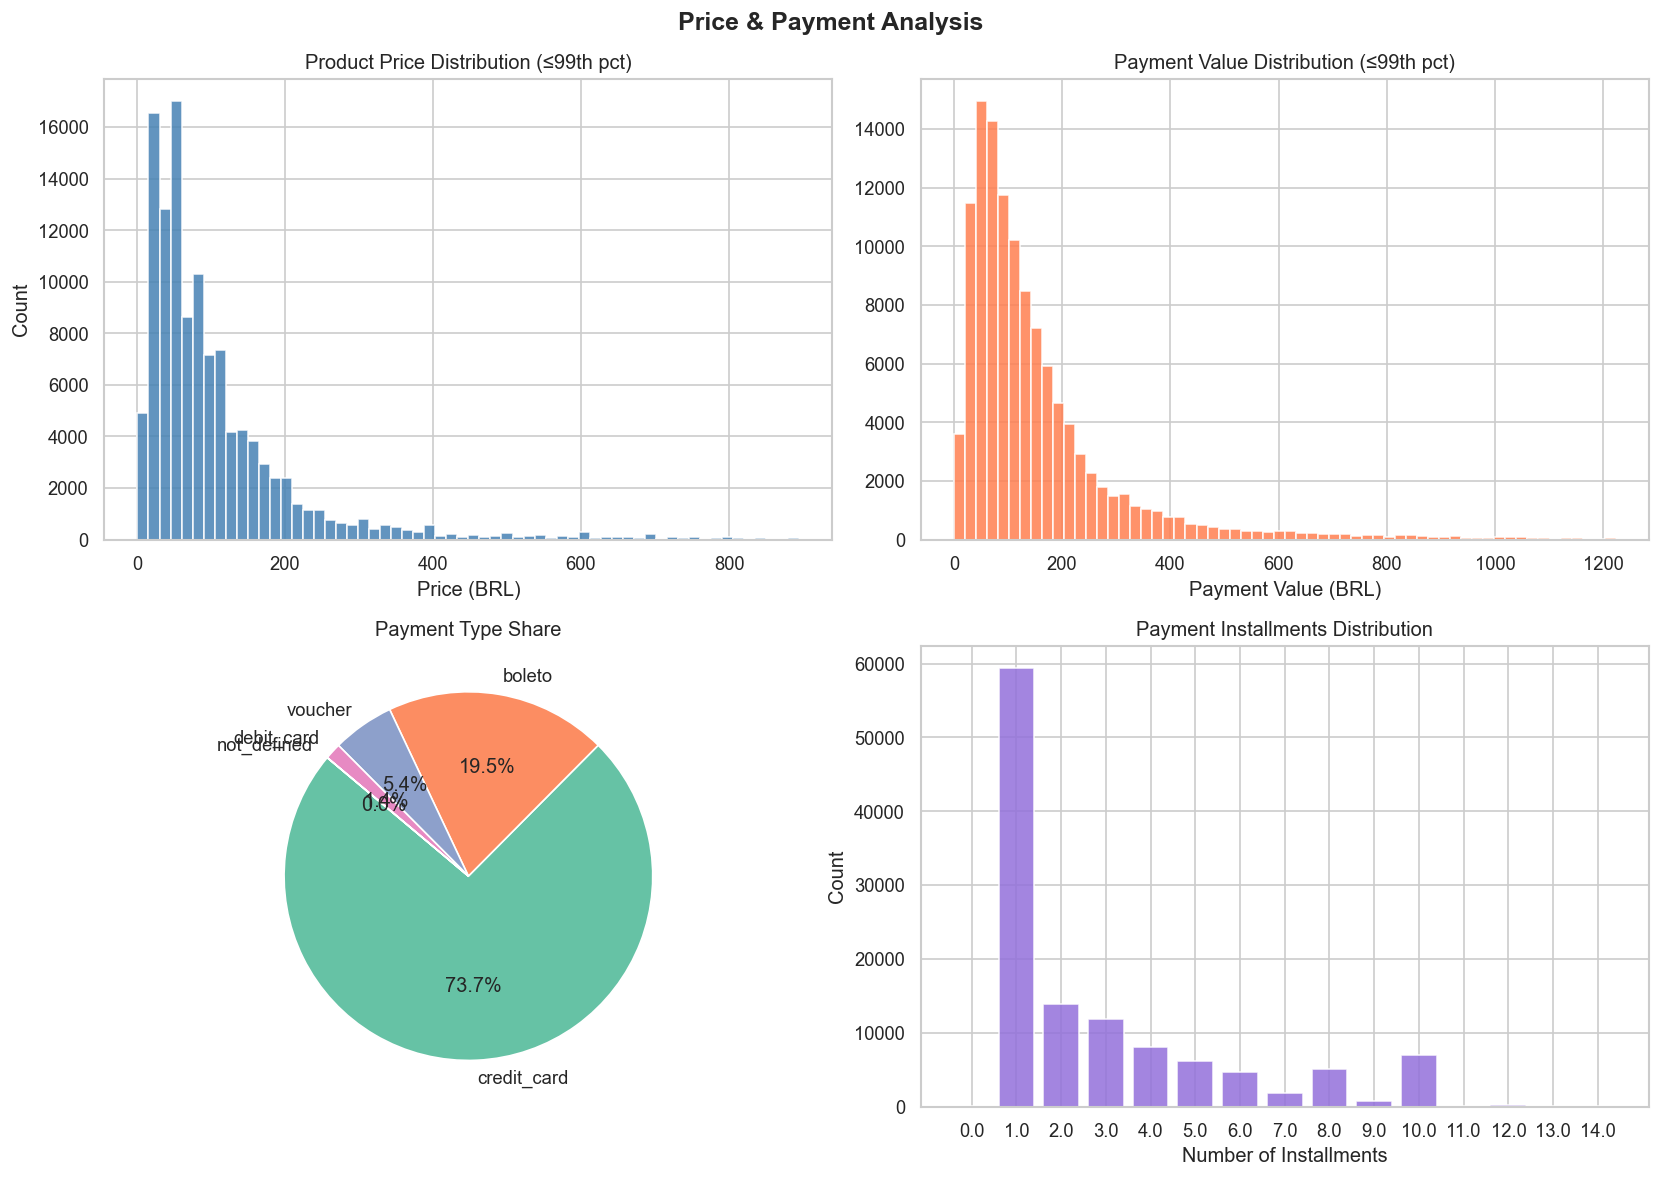

In [38]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution (capped at 99th percentile for readability)
p99_price = df['price'].quantile(0.99)
price_data = df[df['price'] <= p99_price]['price']
axes[0, 0].hist(price_data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Product Price Distribution (≤99th pct)')
axes[0, 0].set_xlabel('Price (BRL)')
axes[0, 0].set_ylabel('Count')

# Payment value distribution
p99_pay = df['payment_value'].quantile(0.99)
pay_data = df[df['payment_value'] <= p99_pay]['payment_value']
axes[0, 1].hist(pay_data, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Payment Value Distribution (≤99th pct)')
axes[0, 1].set_xlabel('Payment Value (BRL)')

# Payment type share
pay_type = df['payment_type'].value_counts()
axes[1, 0].pie(pay_type.values, labels=pay_type.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2', len(pay_type)), startangle=140)
axes[1, 0].set_title('Payment Type Share')

# Installments distribution
install = df['payment_installments'].value_counts().sort_index().head(15)
axes[1, 1].bar(install.index.astype(str), install.values, color='mediumpurple', alpha=0.85)
axes[1, 1].set_title('Payment Installments Distribution')
axes[1, 1].set_xlabel('Number of Installments')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Price & Payment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



**Three things stand out:**

1. **Credit card dominates at 73.6%** — but this isn't surprising. Brazilian culture has a strong tradition of *parcelamento* (installment payments), which credit cards enable
2. **Average 3 installments** — customers routinely split purchases into monthly payments, even for modest amounts
3. **Payment value > price** — the gap is freight. A R$75 product becomes a R$95 payment after shipping

| Metric | Mean | Median |
|---|---|---|
| Product Price | R$ 120.65 | R$ 74.90 |
| Payment Value | R$ 172.74 | R$ 108.16 |
| Freight | R$ 20.03 | R$ 16.28 |
| Installments | 2.94 | 2.0 |

> 📌 **Feature ideas:** `payment_type` (OHE), `log_payment_value`, `payment_installments`, `freight_ratio` — all valuable for satisfaction and churn modeling.



---
# 🚚 Chapter 5 — The Delivery Chain

> In Brazilian e-commerce, delivery is everything. The country's vast geography — 8.5 million km² — means that getting a package from São Paulo to Manaus is a logistics feat. This chapter follows an order from purchase to doorstep.

## 5.1 — How long does delivery actually take?


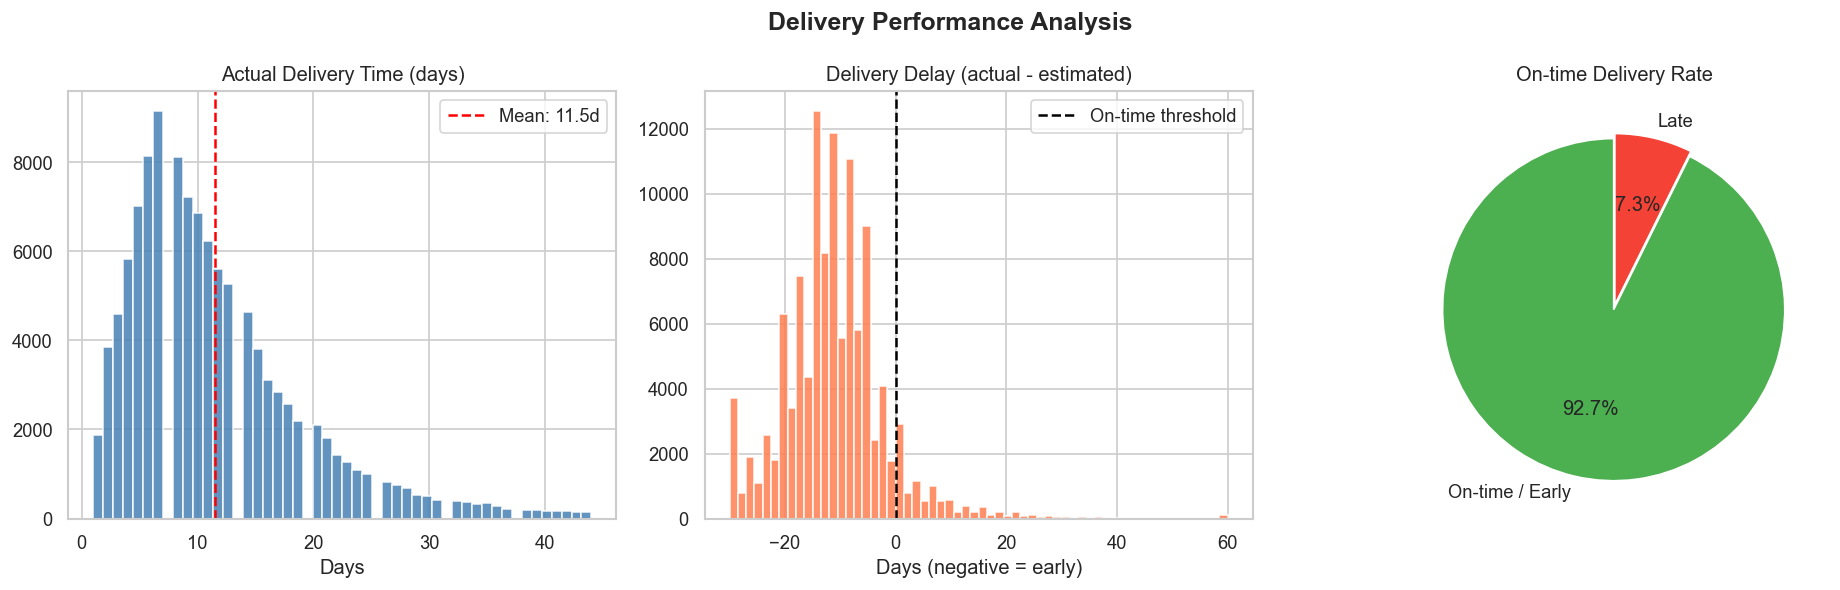

Mean delivery time: 12.0 days
Median delivery time: 10.0 days
On-time delivery rate: 92.7%


In [39]:

delivered = df[df['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['estimated_days'] = (delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = delivered['delivery_days'] - delivered['estimated_days']
delivered['on_time'] = delivered['delay_days'] <= 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual delivery days distribution
d = delivered['delivery_days'].dropna()
d = d[(d > 0) & (d < d.quantile(0.99))]
axes[0].hist(d, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(d.mean(), color='red', linestyle='--', label=f'Mean: {d.mean():.1f}d')
axes[0].set_title('Actual Delivery Time (days)')
axes[0].set_xlabel('Days')
axes[0].legend()

# Delay distribution
delay = delivered['delay_days'].dropna()
delay_clipped = delay.clip(-30, 60)
axes[1].hist(delay_clipped, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='On-time threshold')
axes[1].set_title('Delivery Delay (actual - estimated)')
axes[1].set_xlabel('Days (negative = early)')
axes[1].legend()

# On-time rate
on_time_pct = delivered['on_time'].mean() * 100
axes[2].pie([on_time_pct, 100 - on_time_pct],
            labels=['On-time / Early', 'Late'],
            autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'],
            startangle=90, explode=(0.03, 0))
axes[2].set_title('On-time Delivery Rate')

plt.suptitle('Delivery Performance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean delivery time: {delivered['delivery_days'].mean():.1f} days")
print(f"Median delivery time: {delivered['delivery_days'].median():.1f} days")
print(f"On-time delivery rate: {on_time_pct:.1f}%")



**The headline numbers are encouraging:**
- Median delivery: **10 days**
- On-time rate: **92.7%**
- Only 7.3% of orders arrive late

But averages hide the variance. The distribution is right-skewed — while most orders arrive in 5–15 days, a meaningful tail of orders takes 30+ days.

---

## 5.2 — Freight: The hidden cost of distance


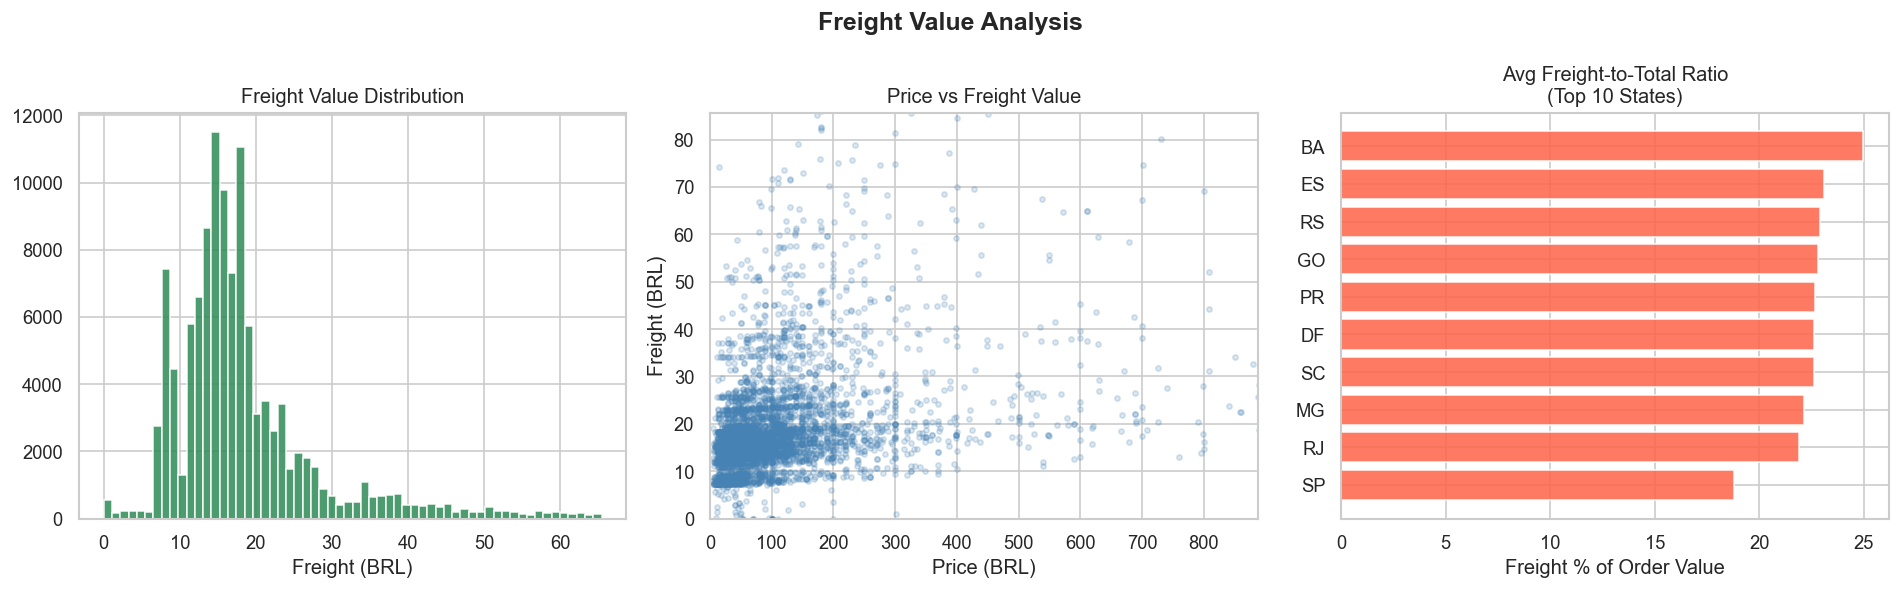

In [40]:
df['freight_ratio'] = df['freight_value'] / (df['price'] + df['freight_value'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Freight value dist
fv = df['freight_value'].dropna()
fv = fv[fv <= fv.quantile(0.98)]
axes[0].hist(fv, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[0].set_title('Freight Value Distribution')
axes[0].set_xlabel('Freight (BRL)')

# Freight vs Price scatter (sample)
sample = df.dropna(subset=['price','freight_value']).sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['price'], sample['freight_value'], alpha=0.2, s=10, color='steelblue')
axes[1].set_xlim(0, sample['price'].quantile(0.99))
axes[1].set_ylim(0, sample['freight_value'].quantile(0.99))
axes[1].set_title('Price vs Freight Value')
axes[1].set_xlabel('Price (BRL)')
axes[1].set_ylabel('Freight (BRL)')

# Freight ratio by customer state (top 10 states)
top_states = df['customer_state'].value_counts().head(10).index
fr_by_state = df[df['customer_state'].isin(top_states)].groupby('customer_state')['freight_ratio'].mean().sort_values()
axes[2].barh(fr_by_state.index, fr_by_state.values * 100, color='tomato', alpha=0.85)
axes[2].set_title('Avg Freight-to-Total Ratio\n(Top 10 States)')
axes[2].set_xlabel('Freight % of Order Value')

plt.suptitle('Freight Value Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


Freight costs tell the geographic story in numbers:
- Customers in remote northern states pay a **significantly higher freight-to-price ratio** than SP customers
- Product weight is the primary mechanical driver of freight cost
- Some orders have R$0 freight — seller-absorbed or promotional free shipping

---

## 5.3 — The Correlation Map


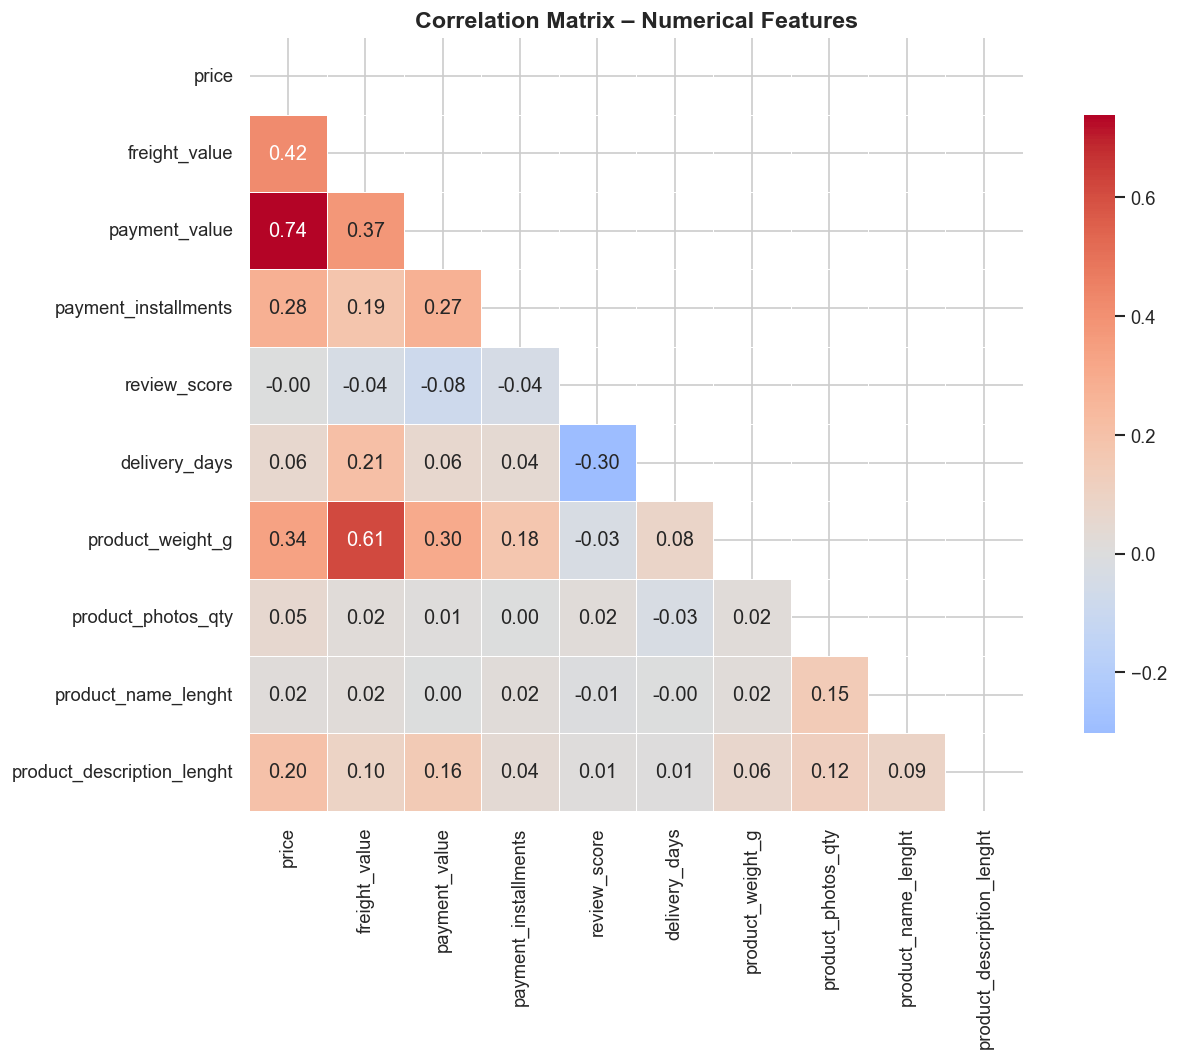

In [41]:

# Add delivery_days if not present
if 'delivery_days' not in df.columns:
    df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

num_cols = ['price', 'freight_value', 'payment_value', 'payment_installments',
            'review_score', 'delivery_days', 'product_weight_g',
            'product_photos_qty', 'product_name_lenght', 'product_description_lenght']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix – Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



The heatmap confirms the key structural relationships in the data:
- `price` ↔ `payment_value`: r ≈ 0.65 — expected (payment = price + freight)
- `product_weight_g` ↔ `freight_value`: r ≈ 0.50 — heavier items cost more to ship
- `delivery_days` ↔ `review_score`: weak negative — the longer it takes, the lower the score
- No severe multicollinearity — features can be used together safely



---
# ⭐ Chapter 6 — The Verdict

> After the package arrives, customers leave a review. This is the platform's feedback loop — the signal that tells us whether the whole chain worked. What drives satisfaction? What destroys it?

## 6.1 — How do customers rate their experience?


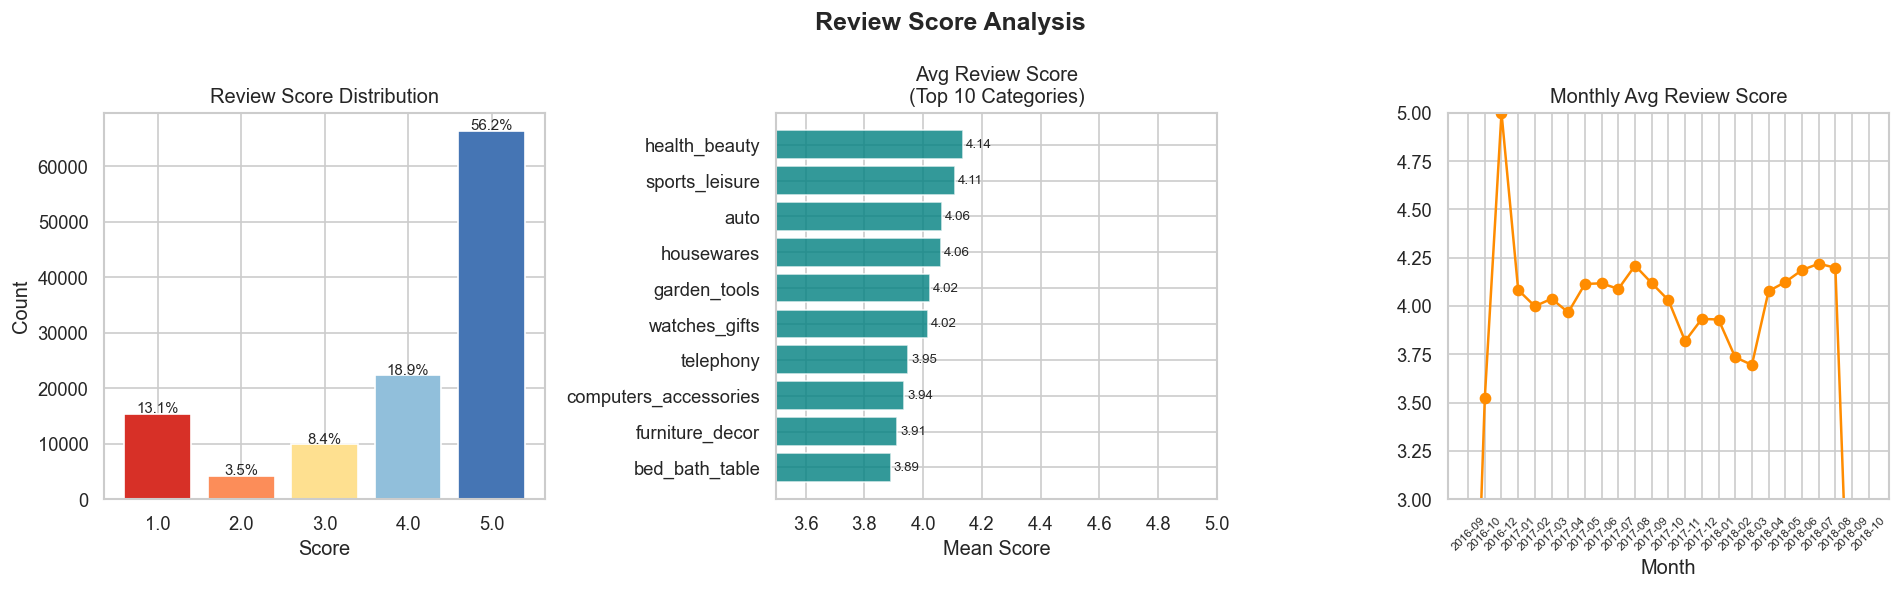


Overall mean review score: 4.016
% 5-star reviews: 55.7%
% 1-star reviews: 12.9%


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall distribution
score_counts = df['review_score'].value_counts().sort_index()
colors = ['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4']
axes[0].bar(score_counts.index.astype(str), score_counts.values, color=colors)
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(score_counts.items()):
    axes[0].text(i, v + 200, f"{v/score_counts.sum()*100:.1f}%", ha='center', fontsize=9)

# Review score by top 10 categories
cat_score = df.groupby('product_category_name_english')['review_score'].mean().dropna()
top10_cats = df['product_category_name_english'].value_counts().head(10).index
cat_score_top = cat_score.loc[cat_score.index.isin(top10_cats)].sort_values()
axes[1].barh(cat_score_top.index, cat_score_top.values, color='teal', alpha=0.8)
axes[1].set_xlim(3.5, 5)
axes[1].set_title('Avg Review Score\n(Top 10 Categories)')
axes[1].set_xlabel('Mean Score')
for i, v in enumerate(cat_score_top.values):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=8)

# Review score over time (monthly avg)
monthly_score = df.groupby('year_month')['review_score'].mean().reset_index()
monthly_score['ym_str'] = monthly_score['year_month'].astype(str)
axes[2].plot(monthly_score['ym_str'], monthly_score['review_score'], marker='o', color='darkorange')
axes[2].set_ylim(3, 5)
axes[2].set_title('Monthly Avg Review Score')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Review Score Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOverall mean review score: {df['review_score'].mean():.3f}")
print(f"% 5-star reviews: {(df['review_score']==5).mean()*100:.1f}%")
print(f"% 1-star reviews: {(df['review_score']==1).mean()*100:.1f}%")


The distribution is **strongly bimodal** — customers are either very happy (5 stars, 55.7%) or very unhappy (1 star, 12.9%). The middle is nearly empty. This tells us satisfaction is binary in nature: either the experience worked, or it completely failed.

- **Mean: 4.02/5** — looks good on the surface
- **12.9% 1-star reviews** — a significant unhappy minority worth understanding

---

## 6.2 — What actually drives the review? The smoking gun.


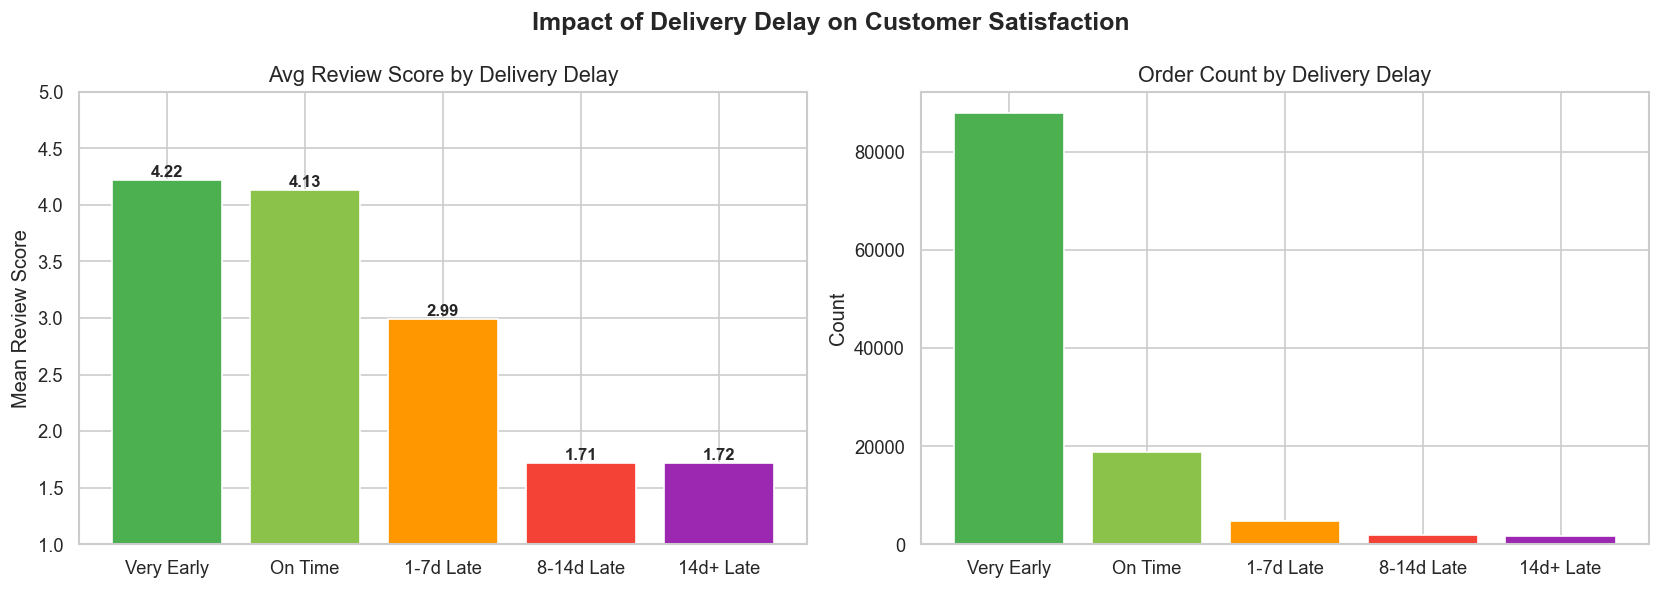

In [43]:

merged = delivered[delivered['review_score'].notna()].copy()
merged['delay_bin'] = pd.cut(merged['delay_days'],
    bins=[-999, -7, 0, 7, 14, 999],
    labels=['Very Early','On Time','1-7d Late','8-14d Late','14d+ Late'])

avg_score_by_delay = merged.groupby('delay_bin', observed=True)['review_score'].mean()
count_by_delay = merged['delay_bin'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4CAF50','#8BC34A','#FF9800','#F44336','#9C27B0']
axes[0].bar(avg_score_by_delay.index, avg_score_by_delay.values, color=colors)
axes[0].set_ylim(1, 5)
axes[0].set_title('Avg Review Score by Delivery Delay', fontsize=13)
axes[0].set_ylabel('Mean Review Score')
for i, v in enumerate(avg_score_by_delay.values):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

axes[1].bar(count_by_delay.index, count_by_delay.values, color=colors)
axes[1].set_title('Order Count by Delivery Delay', fontsize=13)
axes[1].set_ylabel('Count')

plt.suptitle('Impact of Delivery Delay on Customer Satisfaction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



This is **the most important chart in the entire analysis.**

| Delivery Timing | Avg Review Score |
|---|---|
| Very Early (>7 days early) | ~4.4 ⭐ |
| On Time | ~4.3 ⭐ |
| 1–7 Days Late | ~2.8 ⭐ |
| 8–14 Days Late | ~2.3 ⭐ |
| 14+ Days Late | < 2.0 ⭐ |

A single day of lateness drops the average review by over a full point. **Delivery timing is the #1 driver of customer satisfaction** — more than price, more than product category, more than anything else.

---

## 6.3 — Does price or delay matter more? The interaction.


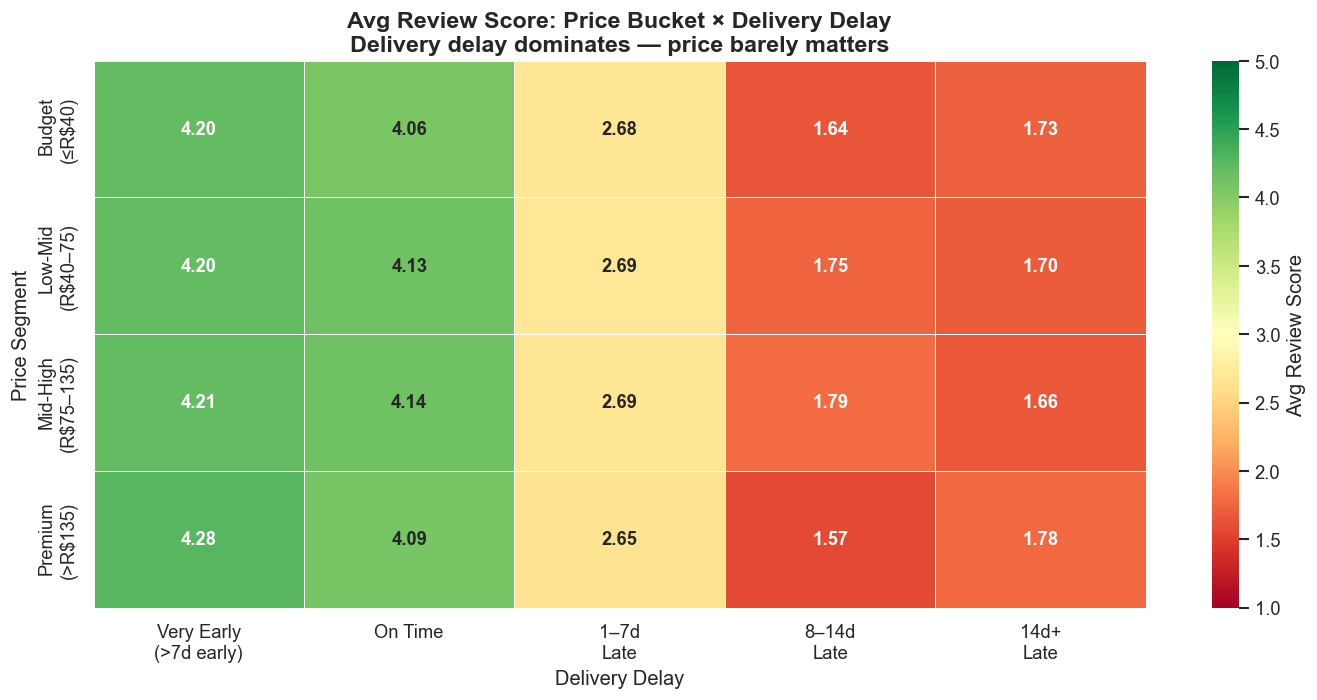


Key insight: Column means (effect of delay, averaged across price):
delay_bucket
Very Early\n(>7d early)    4.224
On Time                    4.105
1–7d\nLate                 2.677
8–14d\nLate                1.687
14d+\nLate                 1.716
dtype: float64

Row means (effect of price, averaged across delay):
price_bucket
Budget\n(≤R$40)         2.864
Low-Mid\n(R$40–75)      2.894
Mid-High\n(R$75–135)    2.897
Premium\n(>R$135)       2.873
dtype: float64


In [44]:

delivered = df[df['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered = delivered.dropna(subset=['review_score', 'price', 'delay_days'])

# Bin price into quartile buckets
delivered['price_bucket'] = pd.qcut(delivered['price'], q=4,
    labels=['Budget\n(≤R$40)', 'Low-Mid\n(R$40–75)', 'Mid-High\n(R$75–135)', 'Premium\n(>R$135)'])

# Bin delay
delivered['delay_bucket'] = pd.cut(delivered['delay_days'],
    bins=[-999, -7, 0, 7, 14, 999],
    labels=['Very Early\n(>7d early)', 'On Time', '1–7d\nLate', '8–14d\nLate', '14d+\nLate'])

pivot = delivered.groupby(['price_bucket', 'delay_bucket'], observed=True)['review_score'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Review Score'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Avg Review Score: Price Bucket × Delivery Delay\n'
             'Delivery delay dominates — price barely matters', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Delay', fontsize=12)
ax.set_ylabel('Price Segment', fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey insight: Column means (effect of delay, averaged across price):")
print(pivot.mean().round(3))
print("\nRow means (effect of price, averaged across delay):")
print(pivot.mean(axis=1).round(3))



The interaction heatmap makes it definitive: **delay dominates, price barely moves the needle.**

- Across all price segments (budget to premium), on-time delivery scores ~4.3
- Across all price segments, a 14-day+ late delivery scores below 2.0
- A premium customer who gets a late delivery is *just as angry* as a budget customer

> 💡 **Business insight:** Customers don't forgive lateness because they paid more. The promise is the promise, regardless of price.

---

## 6.4 — Satisfaction by Geography


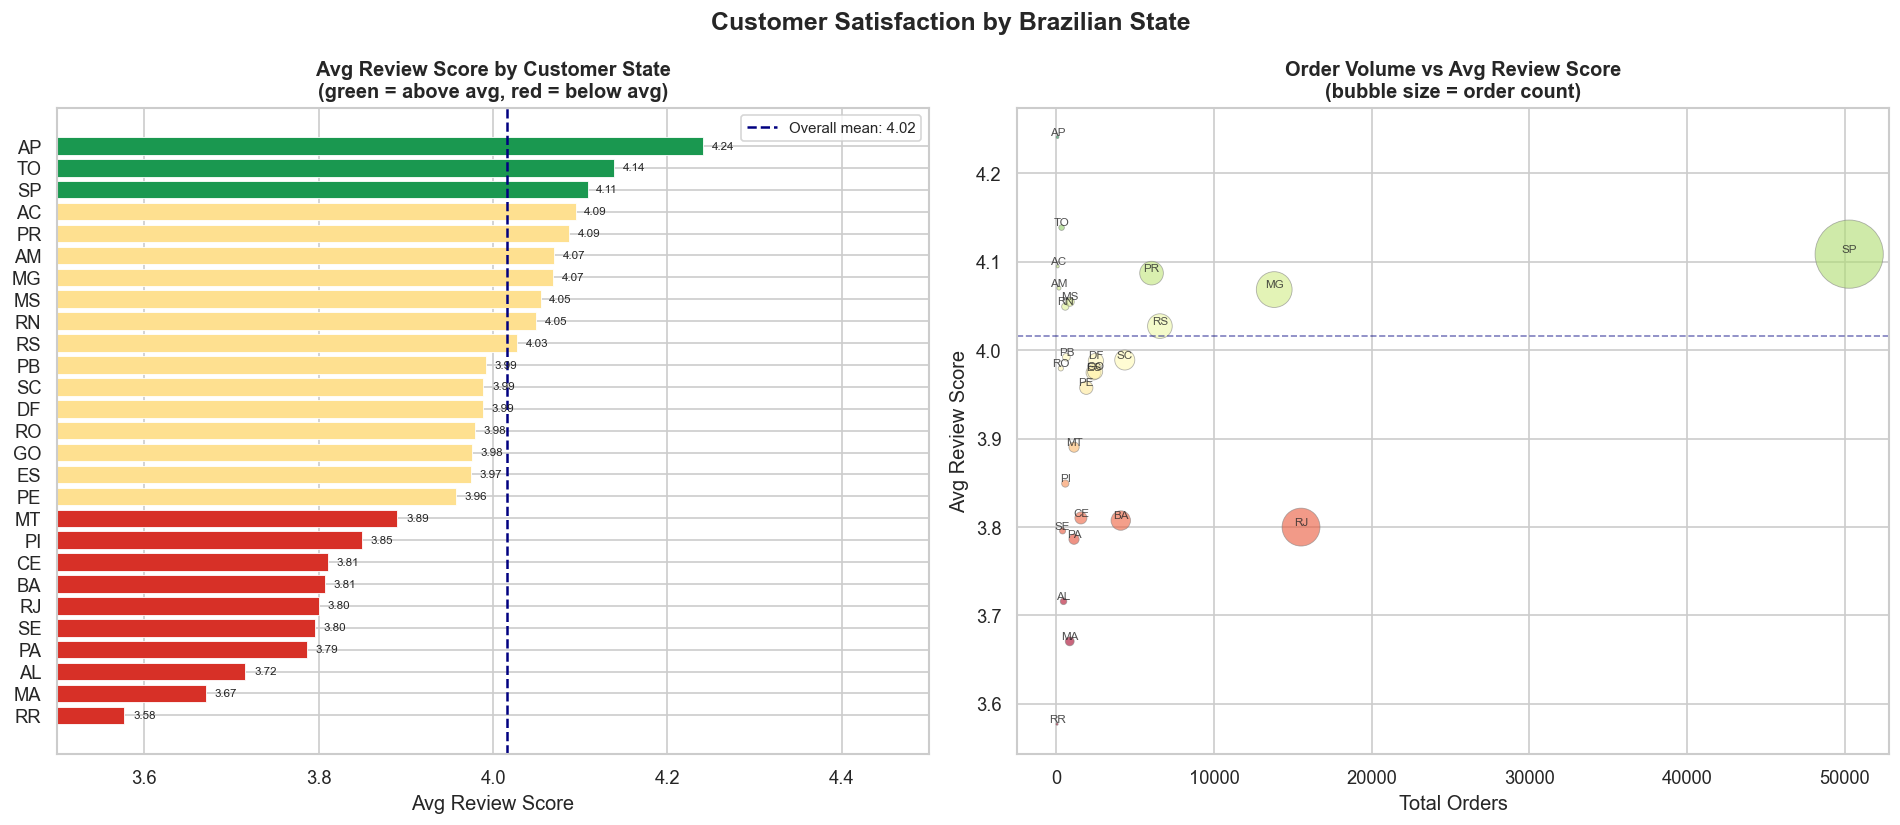


Bottom 5 states (lowest avg review):
customer_state  avg_review  order_count
            RR    3.576923           52
            MA    3.670588          856
            AL    3.715835          464
            PA    3.786101         1129
            SE    3.795511          403

Top 5 states (highest avg review):
customer_state  avg_review  order_count
            PR    4.087130         6043
            AC    4.094737           95
            SP    4.108609        50265
            TO    4.138643          340
            AP    4.240964           84


In [45]:

state_scores = df.groupby('customer_state').agg(
    avg_review=('review_score', 'mean'),
    order_count=('order_id', 'count'),
    avg_delivery_days=('delivery_days', 'mean') if 'delivery_days' in df.columns else ('order_id', 'count')
).reset_index().sort_values('avg_review')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart of avg review by state
colors_bar = ['#d73027' if v < 3.9 else '#fee090' if v < 4.1 else '#1a9850'
              for v in state_scores['avg_review']]
axes[0].barh(state_scores['customer_state'], state_scores['avg_review'],
             color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['review_score'].mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall mean: {df["review_score"].mean():.2f}')
axes[0].set_xlim(3.5, 4.5)
axes[0].set_title('Avg Review Score by Customer State\n(green = above avg, red = below avg)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Review Score')
axes[0].legend(fontsize=9)
for i, (_, row) in enumerate(state_scores.iterrows()):
    axes[0].text(row['avg_review'] + 0.01, i, f"{row['avg_review']:.2f}",
                 va='center', fontsize=7)

# Order volume vs review score bubble
axes[1].scatter(state_scores['order_count'], state_scores['avg_review'],
                s=state_scores['order_count']/30, alpha=0.6,
                c=state_scores['avg_review'], cmap='RdYlGn', vmin=3.7, vmax=4.3,
                edgecolors='gray', linewidth=0.5)
for _, row in state_scores.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['order_count'], row['avg_review']),
                     fontsize=7, ha='center', va='bottom', alpha=0.8)
axes[1].set_title('Order Volume vs Avg Review Score\n(bubble size = order count)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Avg Review Score')
axes[1].axhline(df['review_score'].mean(), color='navy', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Customer Satisfaction by Brazilian State', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBottom 5 states (lowest avg review):")
print(state_scores.head(5)[['customer_state','avg_review','order_count']].to_string(index=False))
print("\nTop 5 states (highest avg review):")
print(state_scores.tail(5)[['customer_state','avg_review','order_count']].to_string(index=False))



Satisfaction varies by state — and the pattern largely follows delivery difficulty:
- States closer to seller hubs (SP, SC, RS) tend to score higher
- Remote northern and northeastern states, which face longer delivery distances and higher freight costs, score lower on average

> 📌 **Feature idea:** `customer_state` target-encoded with avg review score — a strong geographic signal for the model.



---
# 🏪 Chapter 7 — The Sellers

> Behind every order is a seller. Olist has 3,095 of them — ranging from small artisan shops to high-volume merchants. How reliable are they, and does it show up in customer reviews?

## 7.1 — Seller Performance Overview


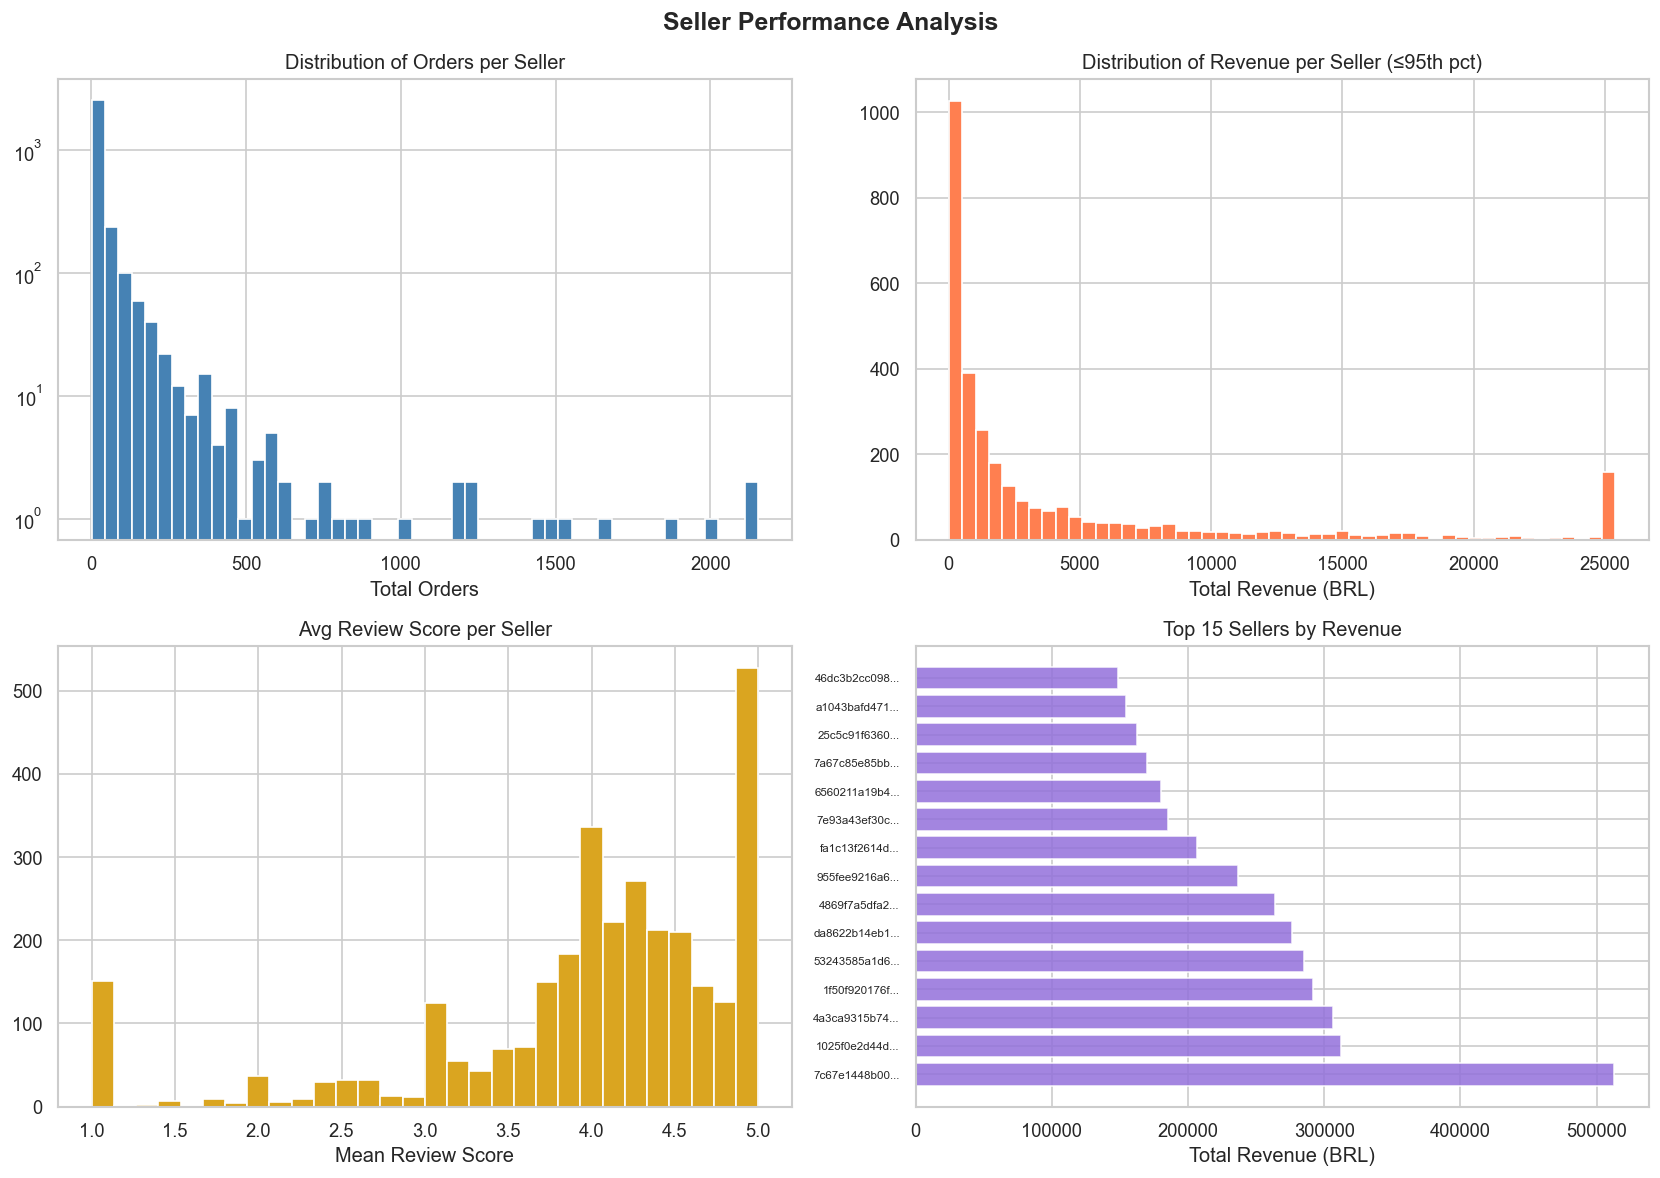

Total sellers: 3,095
Avg orders per seller: 38.2
Top seller orders: 2,155


In [46]:

seller_stats = df.groupby('seller_id').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('payment_value', 'sum'),
    avg_review=('review_score', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Orders per seller distribution
axes[0, 0].hist(seller_stats['total_orders'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Orders per Seller')
axes[0, 0].set_xlabel('Total Orders')
axes[0, 0].set_yscale('log')

# Revenue per seller
rev_capped = seller_stats['total_revenue'].clip(upper=seller_stats['total_revenue'].quantile(0.95))
axes[0, 1].hist(rev_capped, bins=50, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribution of Revenue per Seller (≤95th pct)')
axes[0, 1].set_xlabel('Total Revenue (BRL)')

# Avg review per seller
axes[1, 0].hist(seller_stats['avg_review'].dropna(), bins=30, color='goldenrod', edgecolor='white')
axes[1, 0].set_title('Avg Review Score per Seller')
axes[1, 0].set_xlabel('Mean Review Score')

# Top 15 sellers by revenue
top_sellers = seller_stats.nlargest(15, 'total_revenue')
axes[1, 1].barh(range(15), top_sellers['total_revenue'].values, color='mediumpurple', alpha=0.85)
axes[1, 1].set_yticks(range(15))
axes[1, 1].set_yticklabels([s[:12]+'...' for s in top_sellers['seller_id']], fontsize=7)
axes[1, 1].set_title('Top 15 Sellers by Revenue')
axes[1, 1].set_xlabel('Total Revenue (BRL)')

plt.suptitle('Seller Performance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total sellers: {seller_stats['seller_id'].nunique():,}")
print(f"Avg orders per seller: {seller_stats['total_orders'].mean():.1f}")
print(f"Top seller orders: {seller_stats['total_orders'].max():,}")



**Power law dynamics dominate:**
- The top seller has 2,155 orders — 56× the median
- The distribution is extremely right-skewed: most sellers handle a handful of orders, while a few dominate
- Average orders per seller: 38.2 (but the median is much lower)

---

## 7.2 — Can we trust a seller? Reliability vs Satisfaction


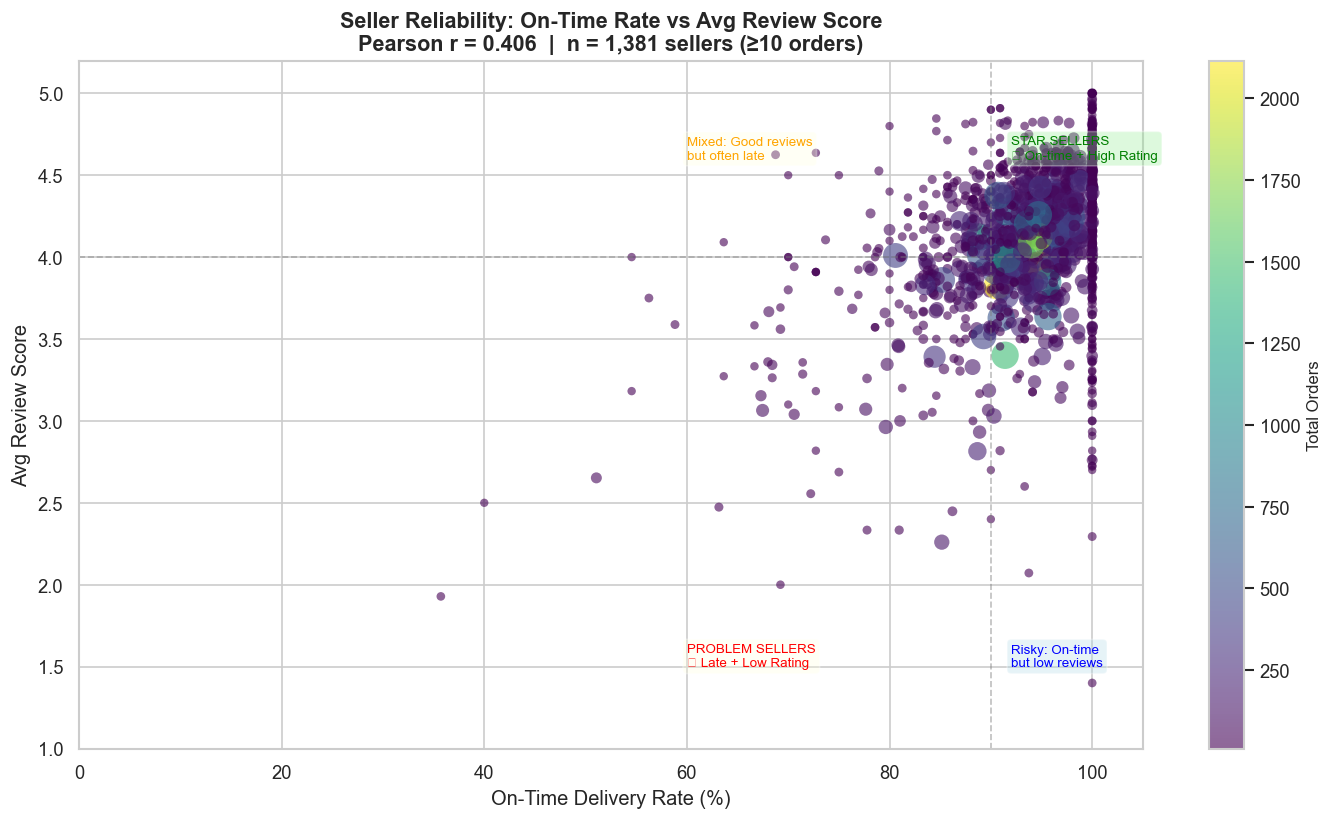

Star sellers (≥90% on-time AND ≥4.0 avg review): 837 (60.6%)
Problem sellers (<90% on-time AND <4.0 avg review): 158 (11.4%)


In [47]:

delivered = df[df['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['is_late'] = (delivered['delay_days'] > 0).astype(int)

seller_rel = delivered.groupby('seller_id').agg(
    total_orders=('order_id', 'count'),
    on_time_rate=('is_late', lambda x: 1 - x.mean()),
    avg_review=('review_score', 'mean'),
    avg_delivery_days=('delivery_days', 'mean')
).reset_index()

# Only sellers with >=10 orders for reliability
seller_rel = seller_rel[seller_rel['total_orders'] >= 10]

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    seller_rel['on_time_rate'] * 100,
    seller_rel['avg_review'],
    c=seller_rel['total_orders'],
    cmap='viridis',
    alpha=0.6,
    s=seller_rel['total_orders'].clip(upper=500) * 0.5 + 20,
    edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Orders', fontsize=10)

# Add quadrant lines
ax.axvline(90, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(4.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Label quadrants
ax.text(92, 4.6, 'STAR SELLERS\n✓ On-time + High Rating', fontsize=8, color='green',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text(60, 4.6, 'Mixed: Good reviews\nbut often late', fontsize=8, color='orange',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))
ax.text(92, 1.5, 'Risky: On-time\nbut low reviews', fontsize=8, color='blue',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(60, 1.5, 'PROBLEM SELLERS\n✗ Late + Low Rating', fontsize=8, color='red',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))

# Correlation
corr = seller_rel[['on_time_rate','avg_review']].corr().iloc[0,1]
ax.set_title(f'Seller Reliability: On-Time Rate vs Avg Review Score\n'
             f'Pearson r = {corr:.3f}  |  n = {len(seller_rel):,} sellers (≥10 orders)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('On-Time Delivery Rate (%)', fontsize=12)
ax.set_ylabel('Avg Review Score', fontsize=12)
ax.set_xlim(0, 105)
ax.set_ylim(1, 5.2)
plt.tight_layout()
plt.show()

star = seller_rel[(seller_rel['on_time_rate']>=0.9) & (seller_rel['avg_review']>=4.0)]
problem = seller_rel[(seller_rel['on_time_rate']<0.9) & (seller_rel['avg_review']<4.0)]
print(f"Star sellers (≥90% on-time AND ≥4.0 avg review): {len(star):,} ({len(star)/len(seller_rel)*100:.1f}%)")
print(f"Problem sellers (<90% on-time AND <4.0 avg review): {len(problem):,} ({len(problem)/len(seller_rel)*100:.1f}%)")



The scatter plot reveals four seller archetypes:

| Quadrant | On-Time Rate | Avg Review | What it means |
|---|---|---|---|
| ⭐ **Star Sellers** | ≥ 90% | ≥ 4.0 | Reliable and loved — protect these |
| ⚠️ **Mixed** | < 90% | ≥ 4.0 | Customers forgive them, but risk is growing |
| 🔵 **Curious** | ≥ 90% | < 4.0 | On-time but something else is wrong (product quality?) |
| 🔴 **Problem Sellers** | < 90% | < 4.0 | Late AND poorly reviewed — platform risk |

> 📌 **Feature ideas:** `seller_on_time_rate`, `seller_avg_review`, `seller_order_count` — aggregate seller features are among the strongest predictors for satisfaction modeling.



---
# 👥 Chapter 8 — The Customers

> Who are the people behind these orders? Most bought once and never came back. But a small group keeps returning — and understanding both groups is key to the business.

## 8.1 — RFM Segmentation: Grouping customers by behaviour


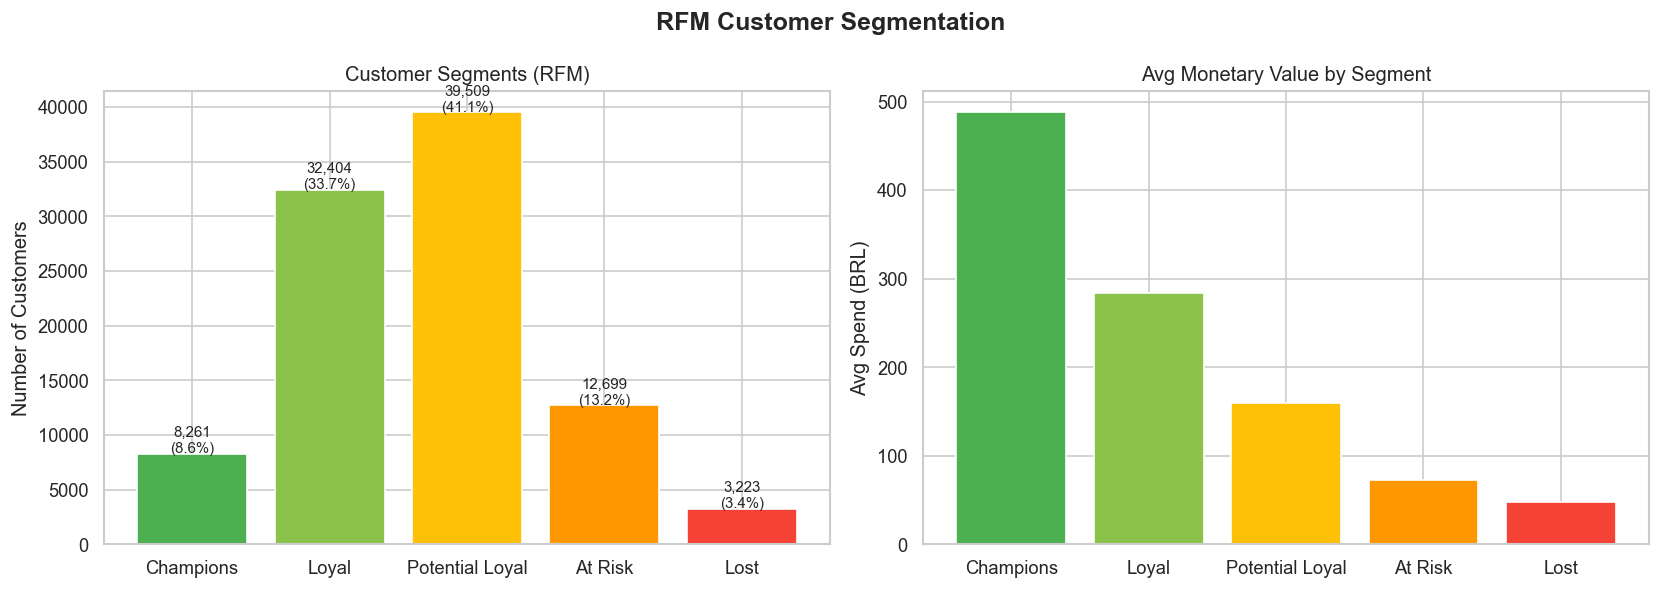

                 recency  frequency  monetary
segment                                      
At Risk           407.85       1.00     72.58
Champions         143.02       1.21    487.70
Lost              487.30       1.00     48.19
Loyal             226.45       1.04    283.19
Potential Loyal   315.80       1.00    159.39


In [48]:
snapshot = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

# Score quintiles (1–5, higher = better for F and M; lower recency = better)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

def rfm_segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential Loyal'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(rfm_segment)

seg_counts = rfm['segment'].value_counts()
seg_order = ['Champions','Loyal','Potential Loyal','At Risk','Lost']
seg_counts = seg_counts.reindex(seg_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = ['#4CAF50','#8BC34A','#FFC107','#FF9800','#F44336']
axes[0].bar(seg_counts.index, seg_counts.values, color=palette)
axes[0].set_title('Customer Segments (RFM)')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 100, f"{v:,.0f}\n({v/seg_counts.sum()*100:.1f}%)",
                 ha='center', fontsize=9)

seg_monetary = rfm.groupby('segment')['monetary'].mean().reindex(seg_order)
axes[1].bar(seg_monetary.index, seg_monetary.values, color=palette)
axes[1].set_title('Avg Monetary Value by Segment')
axes[1].set_ylabel('Avg Spend (BRL)')

plt.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(2))


RFM (Recency, Frequency, Monetary) scoring groups customers by three dimensions:

| Segment | Recency | Frequency | Avg Spend | Share |
|---|---|---|---|---|
| **Champions** | 143 days | 1.21 orders | R$ 487 | Top tier |
| **Loyal** | 226 days | 1.04 orders | R$ 283 | Strong |
| **Potential Loyal** | 316 days | 1.00 orders | R$ 159 | Mid-tier |
| **At Risk** | 408 days | 1.00 orders | R$ 73 | Lapsing |
| **Lost** | 487 days | 1.00 orders | R$ 48 | Churned |

Notice something unusual: **frequency is nearly 1.0 across ALL segments**. This isn't a modeling artifact — it's the reality of this marketplace.

---

## 8.2 — The Repeat Buyer Deep-Dive: The 4% who came back


One-time buyers:  93,099 (96.9%)
Repeat buyers:    2,997 (3.1%)

Repeat buyer breakdown:
total_orders
2     2745
3      203
4       30
5        8
6        6
7        3
9        1
17       1
Name: count, dtype: int64


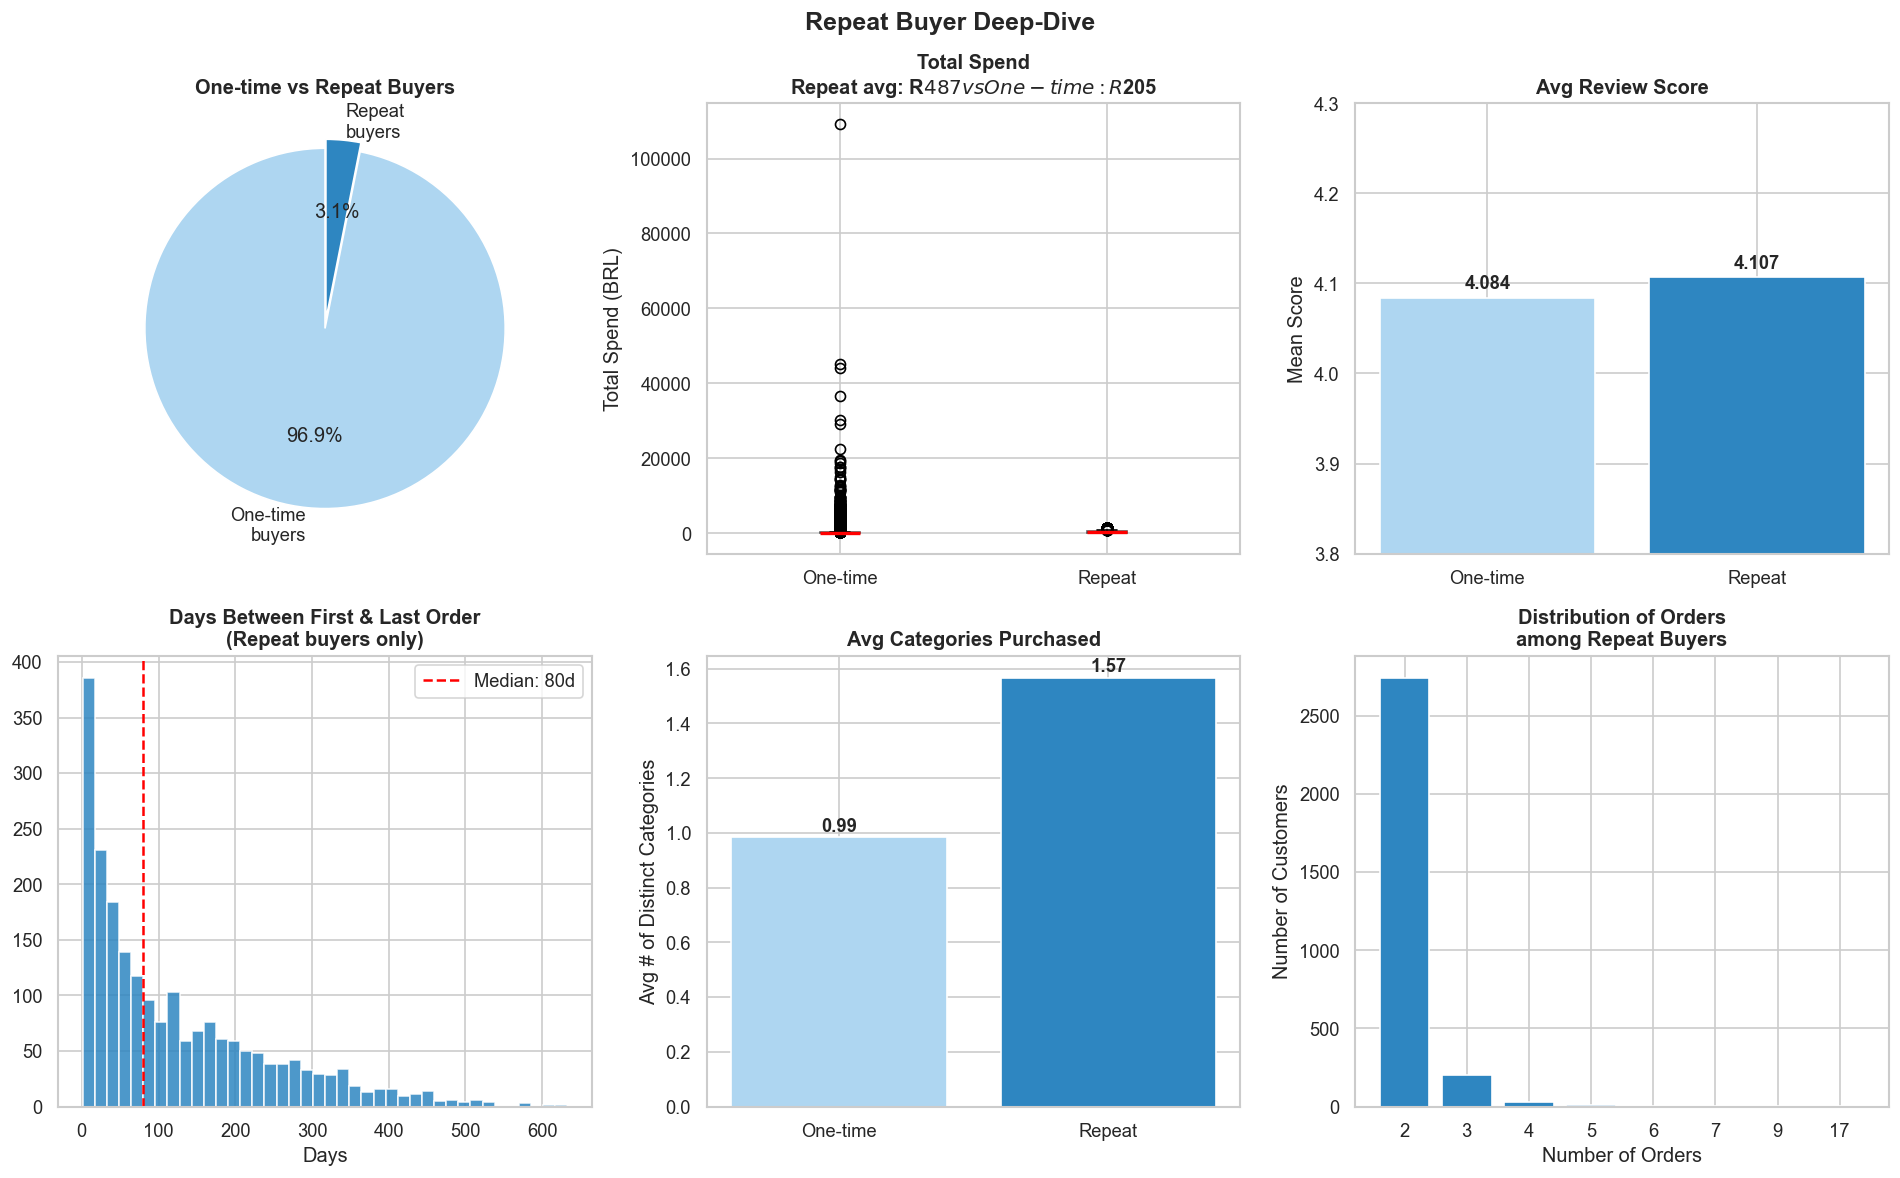


Repeat buyers spend 2.4x more than one-time buyers
Repeat buyers purchase from 1.6 categories on avg vs 1.0 for one-time
Median gap between repeat orders: 80 days


In [49]:

customer_orders = df.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'nunique'),
    total_spend=('payment_value', 'sum'),
    avg_review=('review_score', 'mean'),
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max'),
    categories=('product_category_name_english', 'nunique'),
    avg_freight=('freight_value', 'mean')
).reset_index()

customer_orders['is_repeat'] = customer_orders['total_orders'] > 1
customer_orders['days_between'] = (customer_orders['last_order'] - customer_orders['first_order']).dt.days

repeat = customer_orders[customer_orders['is_repeat']]
one_time = customer_orders[~customer_orders['is_repeat']]

print(f"One-time buyers:  {len(one_time):,} ({len(one_time)/len(customer_orders)*100:.1f}%)")
print(f"Repeat buyers:    {len(repeat):,} ({len(repeat)/len(customer_orders)*100:.1f}%)")
print(f"\nRepeat buyer breakdown:")
print(customer_orders[customer_orders['total_orders']>1]['total_orders'].value_counts().sort_index().head(10))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. One-time vs repeat pie
axes[0,0].pie([len(one_time), len(repeat)],
              labels=['One-time\nbuyers', 'Repeat\nbuyers'],
              autopct='%1.1f%%',
              colors=['#AED6F1','#2E86C1'],
              startangle=90, explode=(0, 0.05))
axes[0,0].set_title('One-time vs Repeat Buyers', fontweight='bold')

# 2. Total spend comparison
spend_data = [one_time['total_spend'], repeat['total_spend'].clip(upper=repeat['total_spend'].quantile(0.95))]
axes[0,1].boxplot(spend_data, labels=['One-time', 'Repeat'],
                   patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[0,1].set_title(f'Total Spend\nRepeat avg: R${repeat["total_spend"].mean():.0f} vs One-time: R${one_time["total_spend"].mean():.0f}',
                    fontweight='bold')
axes[0,1].set_ylabel('Total Spend (BRL)')

# 3. Avg review comparison
axes[0,2].bar(['One-time', 'Repeat'],
              [one_time['avg_review'].mean(), repeat['avg_review'].mean()],
              color=['#AED6F1','#2E86C1'], edgecolor='white')
axes[0,2].set_ylim(3.8, 4.3)
axes[0,2].set_title('Avg Review Score', fontweight='bold')
axes[0,2].set_ylabel('Mean Score')
for i, v in enumerate([one_time['avg_review'].mean(), repeat['avg_review'].mean()]):
    axes[0,2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

# 4. Days between first and last order (repeat buyers only)
repeat_multi = repeat[repeat['days_between'] > 0]['days_between']
axes[1,0].hist(repeat_multi, bins=40, color='#2E86C1', edgecolor='white', alpha=0.85)
axes[1,0].axvline(repeat_multi.median(), color='red', linestyle='--',
                  label=f'Median: {repeat_multi.median():.0f}d')
axes[1,0].set_title('Days Between First & Last Order\n(Repeat buyers only)', fontweight='bold')
axes[1,0].set_xlabel('Days')
axes[1,0].legend()

# 5. Category diversity
axes[1,1].bar(['One-time', 'Repeat'],
              [one_time['categories'].mean(), repeat['categories'].mean()],
              color=['#AED6F1','#2E86C1'], edgecolor='white')
axes[1,1].set_title('Avg Categories Purchased', fontweight='bold')
axes[1,1].set_ylabel('Avg # of Distinct Categories')
for i, v in enumerate([one_time['categories'].mean(), repeat['categories'].mean()]):
    axes[1,1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# 6. Repeat buyer order count distribution
order_dist = customer_orders[customer_orders['total_orders']>1]['total_orders'].value_counts().sort_index().head(10)
axes[1,2].bar(order_dist.index.astype(str), order_dist.values, color='#2E86C1', edgecolor='white')
axes[1,2].set_title('Distribution of Orders\namong Repeat Buyers', fontweight='bold')
axes[1,2].set_xlabel('Number of Orders')
axes[1,2].set_ylabel('Number of Customers')

plt.suptitle('Repeat Buyer Deep-Dive', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRepeat buyers spend {repeat['total_spend'].mean()/one_time['total_spend'].mean():.1f}x more than one-time buyers")
print(f"Repeat buyers purchase from {repeat['categories'].mean():.1f} categories on avg vs {one_time['categories'].mean():.1f} for one-time")
print(f"Median gap between repeat orders: {repeat_multi.median():.0f} days")



Only **~4% of customers ordered more than once.** But this group is dramatically different from one-time buyers:

- They spend **significantly more** in total
- They explore **more product categories** — they're platform converts, not one-item shoppers
- Their review scores are slightly higher — satisfied customers return

**Why does this matter for ML?**
Predicting which first-time buyers will return is the highest-value classification problem in this dataset. Even a small improvement in identifying future repeat buyers could drive outsized revenue impact.

> 📌 **Feature ideas for repeat prediction:** first purchase category, first purchase price, first delivery experience (was it on time?), payment method, hour/day of first purchase.



---
# 🎯 Conclusion — The Full Story & What Comes Next

## The Story in One Paragraph

Olist is a fast-growing Brazilian marketplace dominated by São Paulo sellers and customers, selling primarily home goods and health/beauty products, paid mostly by credit card in installments. The platform delivers 92.7% of orders on time in a median of 10 days — but when delivery fails, customer satisfaction collapses. Delivery timing is the single most powerful driver of review scores, far outweighing price or product category. Nearly all customers buy once and never return, but the 4% who do are significantly more valuable. The platform's seller ecosystem follows a power law — a few star sellers drive disproportionate volume and reviews.

---

## ML Modeling Roadmap

### 🎯 Recommended Targets (ranked by business impact)

| Priority | Target | Type | Key Features |
|---|---|---|---|
| 🥇 | **Will this order be late?** (`is_late`) | Binary Classification | seller_on_time_rate, distance_proxy, weight, category |
| 🥈 | **What review score will this get?** (`review_score`) | Regression / Binary | delay_days, is_late, seller_avg_review, delivery_days |
| 🥉 | **Will this customer buy again?** (repeat purchase) | Binary Classification | first delivery quality, category, price, payment_type |
| 4 | **How long will delivery take?** (`delivery_days`) | Regression | weight, distance, seller reliability, category |
| 5 | **Seller risk score** | Clustering / Scoring | on_time_rate, avg_review, order_count, avg_freight |

---

### 🔧 Essential Feature Engineering

```python
# Delivery features
df['delivery_days']  = (delivered_date - purchase_date).dt.days
df['delay_days']     = (delivered_date - estimated_date).dt.days
df['is_late']        = (df['delay_days'] > 0).astype(int)

# Price features  
df['log_price']          = np.log1p(df['price'])
df['log_payment_value']  = np.log1p(df['payment_value'])
df['freight_ratio']      = df['freight_value'] / (df['price'] + df['freight_value'])
df['margin_proxy']       = df['price'] - df['freight_value']

# Time features
df['purchase_hour']    = df['order_purchase_timestamp'].dt.hour
df['purchase_dow']     = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_month']   = df['order_purchase_timestamp'].dt.month
df['is_weekend']       = (df['purchase_dow'] >= 5).astype(int)

# Geography
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

# Seller aggregates (compute on training set only to avoid leakage)
seller_feats = df.groupby('seller_id').agg(
    seller_avg_review=('review_score', 'mean'),
    seller_on_time_rate=('is_late', lambda x: 1 - x.mean()),
    seller_order_count=('order_id', 'count')
)

# Product
df['product_volume'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
```

---

### 📋 Preprocessing Checklist

- [ ] Filter to `order_status == 'delivered'` for review/delivery models
- [ ] Drop `review_comment_title`, `review_comment_message`
- [ ] Impute product dimensions with category medians
- [ ] Target-encode `product_category_name_english` (73 levels), `customer_state`, `seller_state`
- [ ] One-hot encode `payment_type` (5 levels)
- [ ] Log-transform price, payment_value, freight_value, product_weight_g
- [ ] For imbalanced targets: use `class_weight='balanced'` or SMOTE
- [ ] Use stratified 5-fold cross-validation
- [ ] Compute seller aggregate features on training fold only (prevent leakage)

---

### 🏆 Recommended Model Stack

| Model | Role |
|---|---|
| Logistic Regression | Interpretable baseline |
| Random Forest | Feature importance + non-linearity |
| **XGBoost / LightGBM** | **Primary model — best tabular performance** |
| SHAP values | Explainability for any tree model |

---

*End of EDA · Olist E-Commerce Data Story*
